Libary

In [105]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
import seaborn as sns

Dataset

In [106]:
data=pd.read_csv('global_fuel_prices_2020_2026.csv')
data

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4
...,...,...,...,...,...,...,...,...,...,...
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.00,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.00,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.00,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.00,43.7


Data Distribution

In [107]:
data['income_level'].value_counts()

income_level
High      10464
Middle     9483
Low        7521
Name: count, dtype: int64

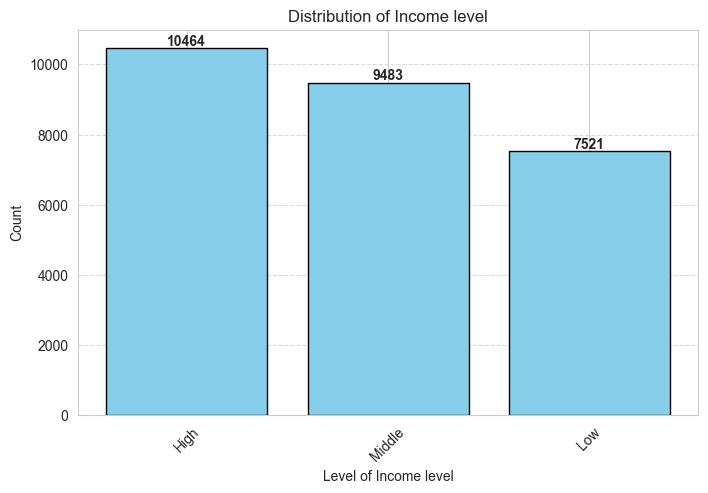

In [108]:
counts = data['income_level'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, int(yval),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Distribution of Income level")
plt.xlabel("Level of Income level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [109]:
data['subsidy_level'].value_counts()

subsidy_level
Low          14388
Medium        5886
High          3924
Very High     3270
Name: count, dtype: int64

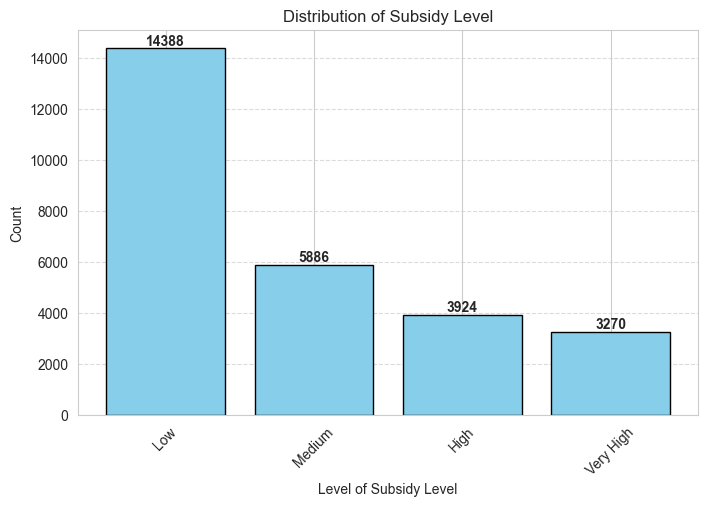

In [110]:
counts2 = data['subsidy_level'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(counts2.index, counts2.values, color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, int(yval),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Distribution of Subsidy Level")
plt.xlabel("Level of Subsidy Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

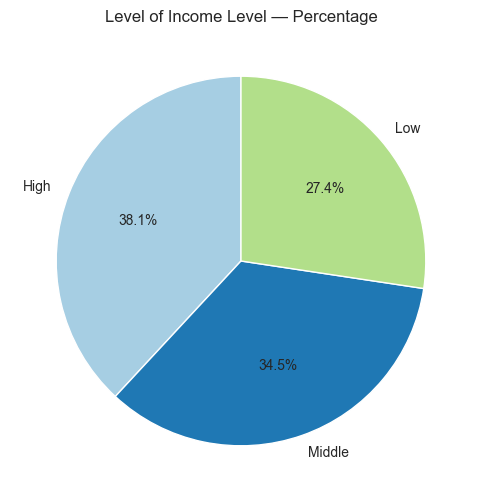

In [111]:
plt.figure(figsize=(6,6))
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.ylabel("")
plt.title("Level of Income Level — Percentage")
plt.show()

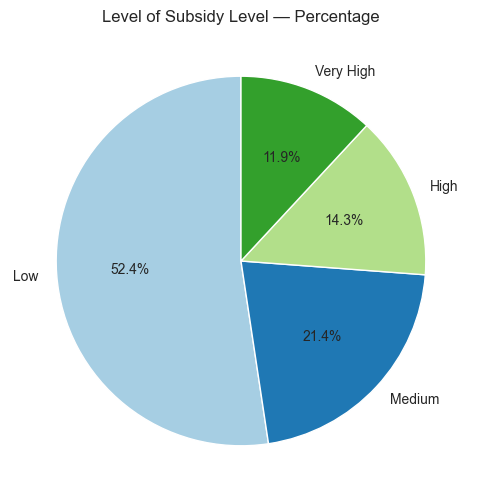

In [112]:
plt.figure(figsize=(6,6))
counts2.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.ylabel("")
plt.title("Level of Subsidy Level — Percentage")
plt.show()

In [113]:
# convert date
data['date'] = pd.to_datetime(data['date'])

# extract
#data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

# drop original
data.drop('date', axis=1, inplace=True)

In [114]:
data.shape

(27468, 10)

Find Unique Value

In [115]:
for col in data.columns:
    print(col, ":", data[col].unique())

country : <StringArray>
[ 'United States',         'Canada',         'Mexico',         'Brazil',
      'Argentina',       'Colombia',          'Chile',           'Peru',
      'Venezuela',        'Ecuador', 'United Kingdom',        'Germany',
         'France',          'Italy',          'Spain',    'Netherlands',
        'Belgium',         'Sweden',         'Norway',        'Denmark',
        'Finland',         'Poland',       'Portugal',         'Greece',
    'Switzerland',        'Austria',        'Ireland',        'Hungary',
 'Czech Republic',        'Romania',         'Russia',        'Ukraine',
         'Turkey',          'China',          'Japan',    'South Korea',
          'India',      'Indonesia',       'Malaysia',       'Thailand',
        'Vietnam',    'Philippines',     'Bangladesh',       'Pakistan',
      'Sri Lanka',          'Nepal',        'Myanmar',      'Singapore',
      'Hong Kong',         'Taiwan',      'Australia',    'New Zealand',
   'Saudi Arabia',         

Count data in every coloum

In [116]:
data.count()

country             27468
region              27468
income_level        27468
subsidy_level       27468
petrol_usd_liter    27468
diesel_usd_liter    27468
lpg_usd_liter       27468
brent_crude_usd     27468
tax_percentage      27468
month               27468
dtype: int64

Find Null Value

In [117]:
data.isnull().sum()

country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
month               0
dtype: int64

In [118]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           27468 non-null  str    
 1   region            27468 non-null  str    
 2   income_level      27468 non-null  str    
 3   subsidy_level     27468 non-null  str    
 4   petrol_usd_liter  27468 non-null  float64
 5   diesel_usd_liter  27468 non-null  float64
 6   lpg_usd_liter     27468 non-null  float64
 7   brent_crude_usd   27468 non-null  float64
 8   tax_percentage    27468 non-null  float64
 9   month             27468 non-null  int32  
dtypes: float64(5), int32(1), str(4)
memory usage: 2.0 MB


Data Prerocessing

In [119]:
le = LabelEncoder()

for col in ['country','region','income_level','subsidy_level']:
    data[col] = le.fit_transform(data[col])
data

,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,month
0,79,4,0,1,1.465,1.289,1.093,65.75,59.6,1
1,79,4,0,1,1.435,1.319,1.077,65.54,27.6,1
2,79,4,0,1,1.446,1.329,1.080,66.51,62.3,1
3,79,4,0,1,1.488,1.359,1.125,68.79,44.8,1
4,79,4,0,1,1.457,1.341,1.111,68.44,51.4,2
...,...,...,...,...,...,...,...,...,...,...
27463,59,0,1,1,3.036,2.849,2.294,130.00,62.3,3
27464,59,0,1,1,3.020,2.861,2.248,130.00,43.3,3
27465,59,0,1,1,3.072,2.825,2.334,130.00,64.1,3
27466,59,0,1,1,3.045,2.816,2.282,130.00,43.7,3


Split Data

In [120]:
#x = data.drop("petrol_usd_liter", axis=1)
x = data.drop(["petrol_usd_liter", "diesel_usd_liter","lpg_usd_liter"], axis=1)
#x = data['diesel_usd_liter']
y= data['petrol_usd_liter']
#x = x.values.reshape(-1,1)
print(x.shape)
print(y.shape)


(27468, 7)
(27468,)


In [121]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

Regression Model Train

In [122]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [123]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(),
    "Support Vector Regression": SVR(),
    "K Nearest Neighbors Regression": KNeighborsRegressor()
}

Model: Linear Regression
R2 Score: 0.5285594507274368
MSE: 1.109692009031248
RMSE: 1.0534191990994126
MAE: 0.8689928546662752
Train: 0.5520896754020477
Test: 0.5285594507274368


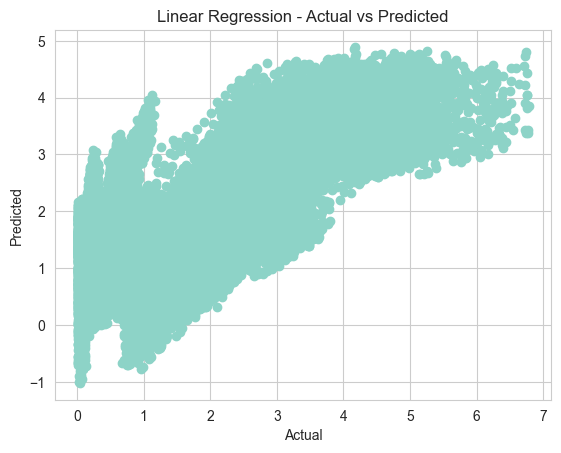

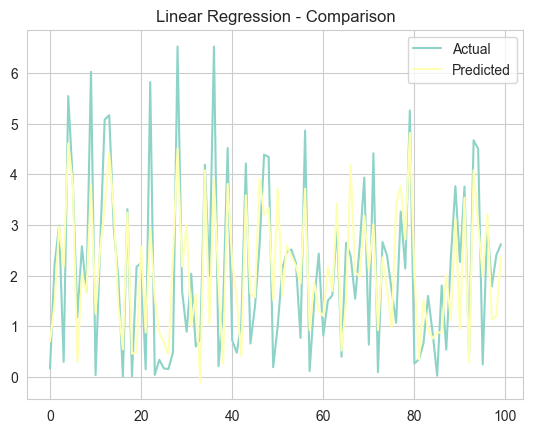

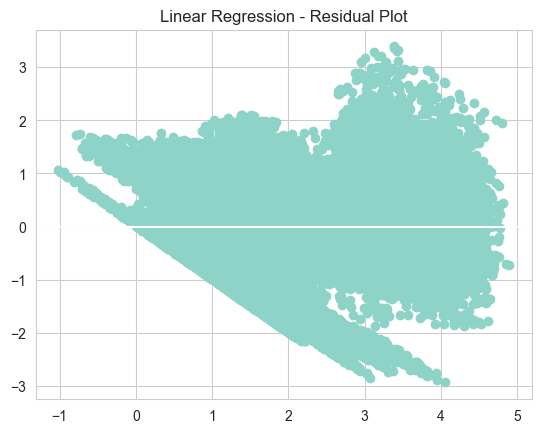

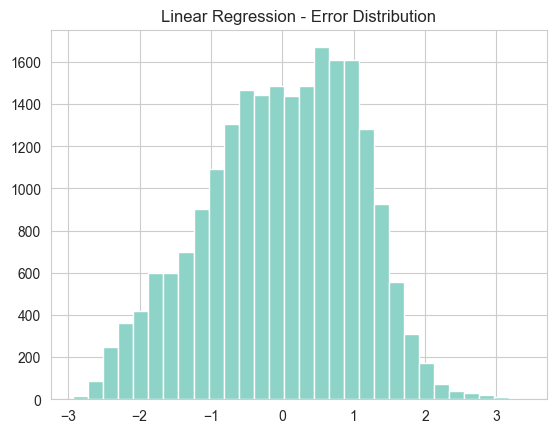

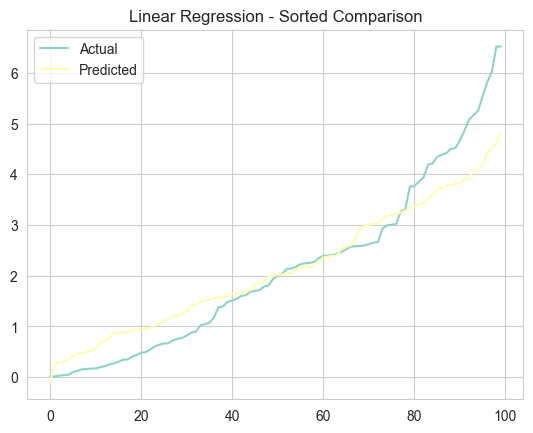

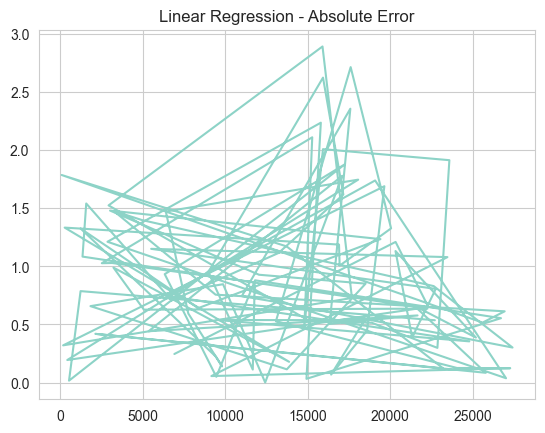


------------------------------------------------------------

Model: Decision Tree Regression
R2 Score: 0.9959594266665432
MSE: 0.009510832165286247
RMSE: 0.09752349545256388
MAE: 0.045401565486484025
Train: 1.0
Test: 0.9959594266665432


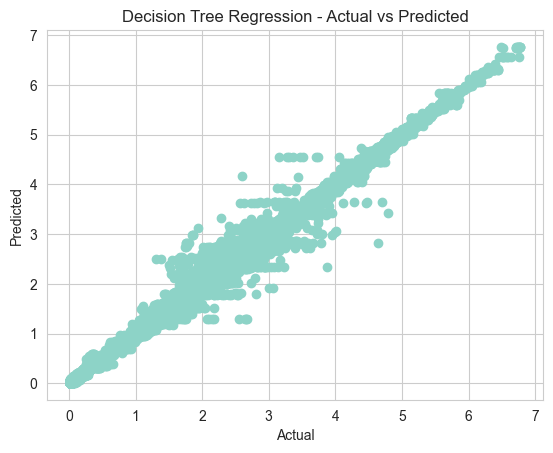

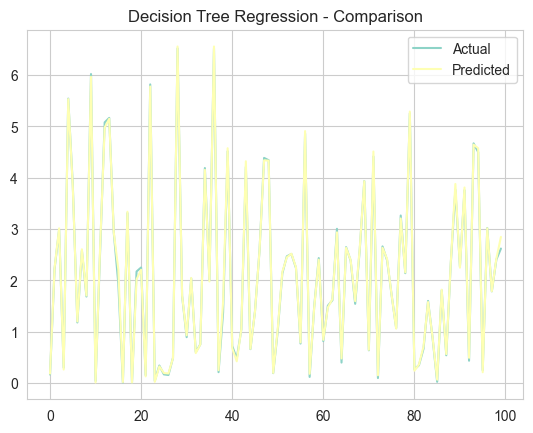

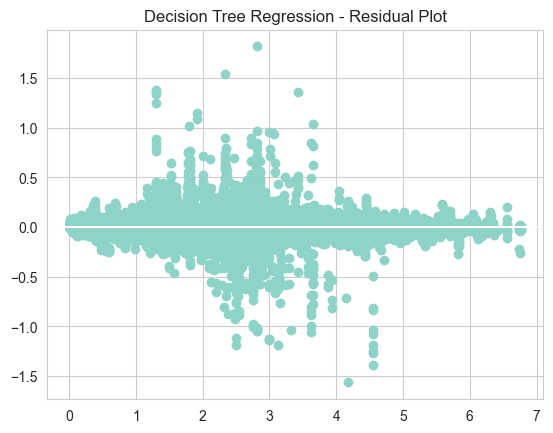

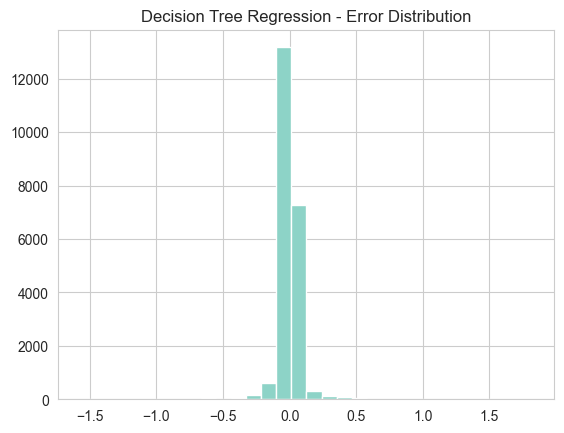

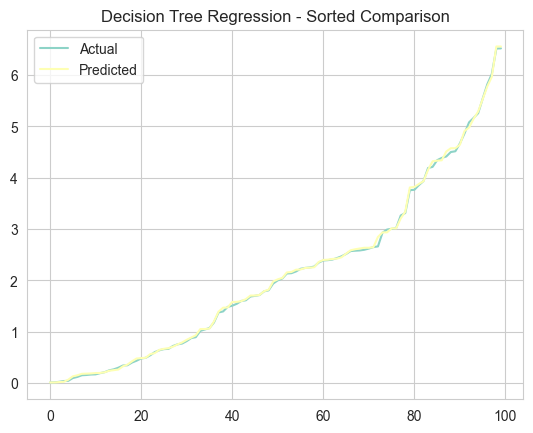

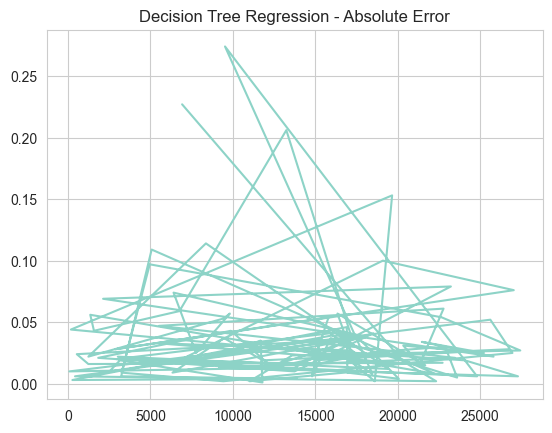


------------------------------------------------------------

Model: Random Forest Regression
R2 Score: 0.9968040580308896
MSE: 0.0075227115485118805
RMSE: 0.08673356644639883
MAE: 0.04260192318194231
Train: 0.9996132310701977
Test: 0.9968040580308896


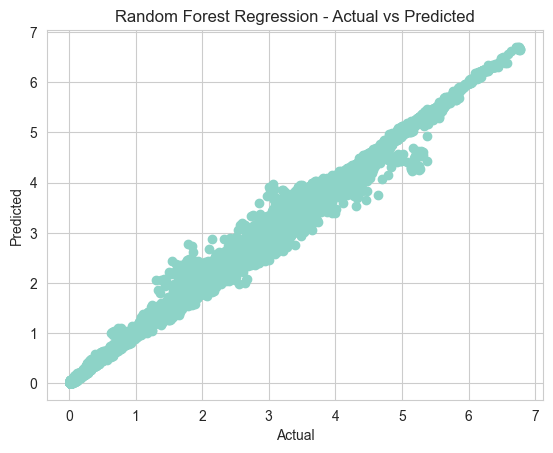

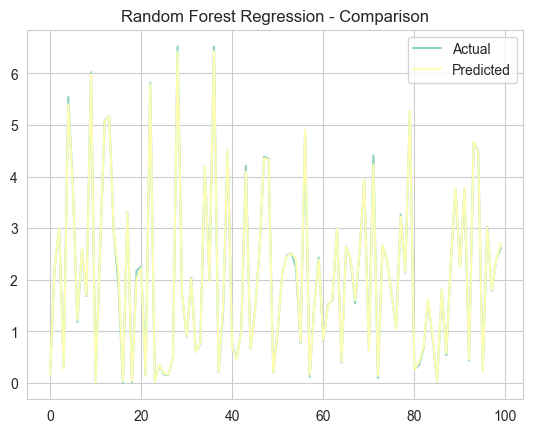

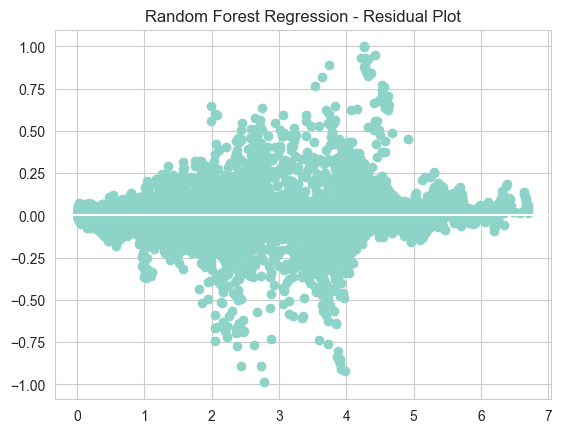

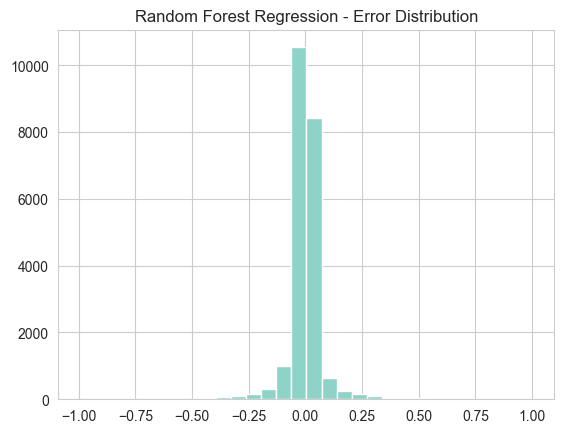

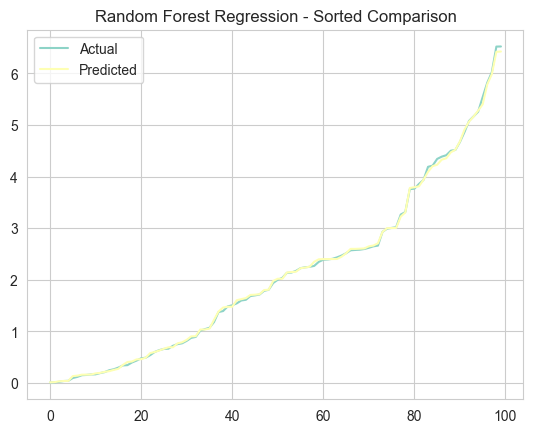

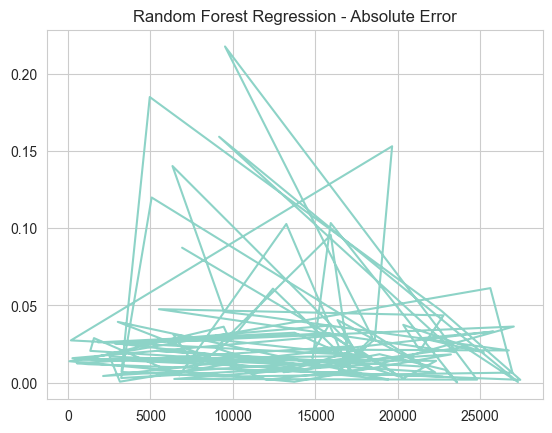


------------------------------------------------------------

Model: Support Vector Regression
R2 Score: 0.46523046156713055
MSE: 1.2587578314762082
RMSE: 1.1219437737588316
MAE: 0.888101995754059
Train: 0.4692398485553976
Test: 0.46523046156713055


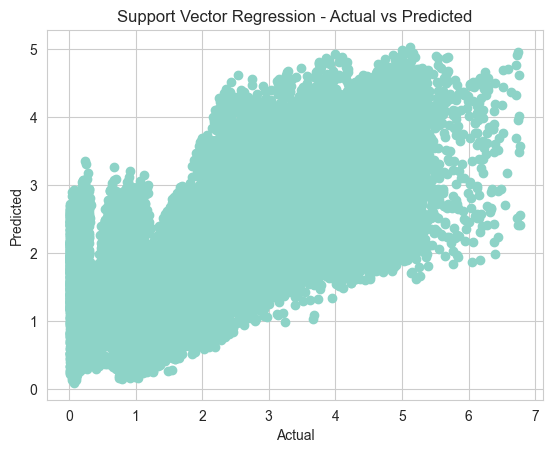

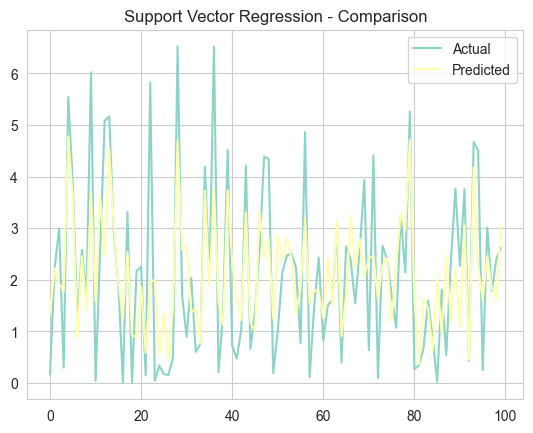

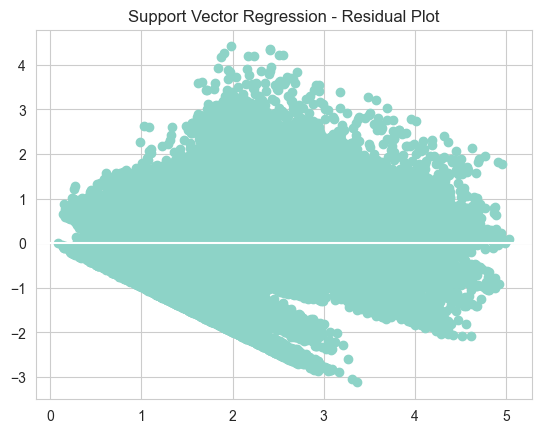

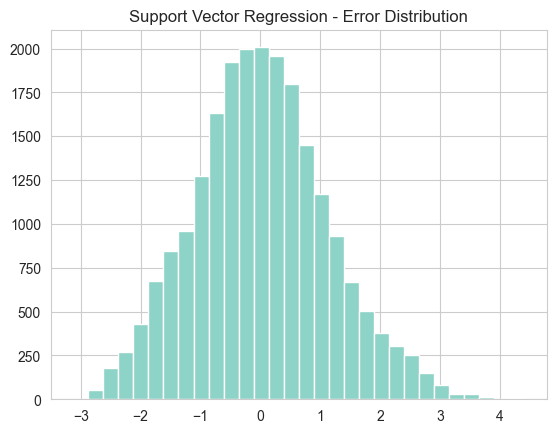

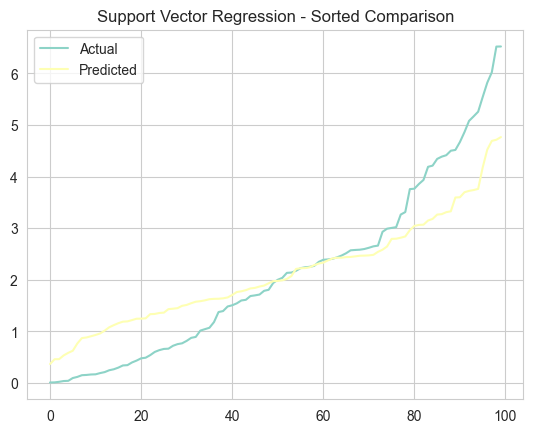

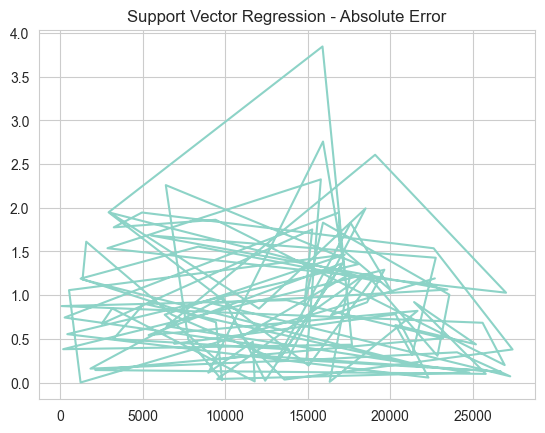


------------------------------------------------------------

Model: K Nearest Neighbors Regression
R2 Score: 0.5693762360876744
MSE: 1.0136161398288888
RMSE: 1.0067850514528356
MAE: 0.7533189314644582
Train: 0.7382105374055357
Test: 0.5693762360876744


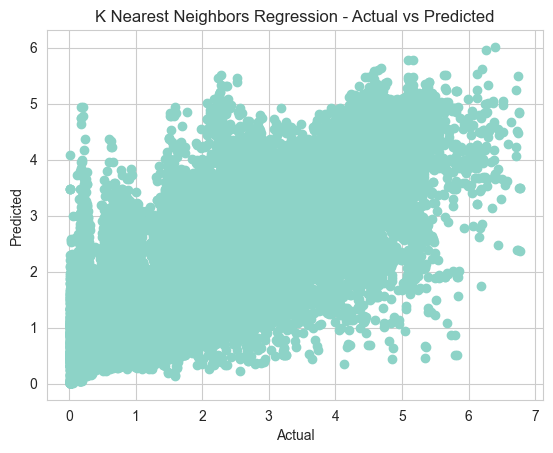

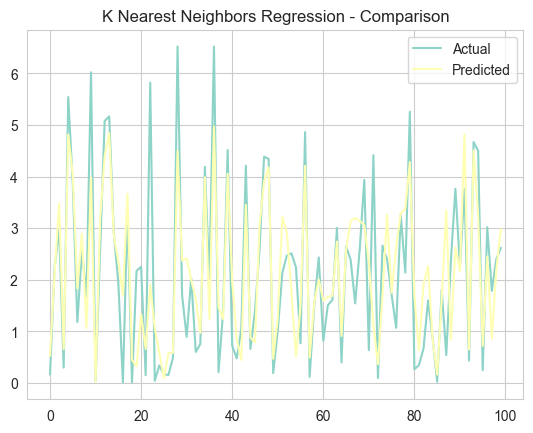

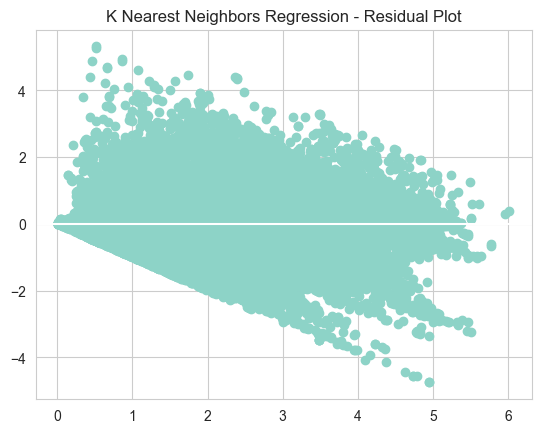

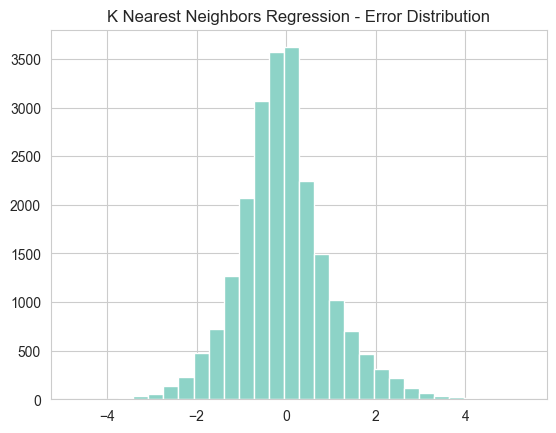

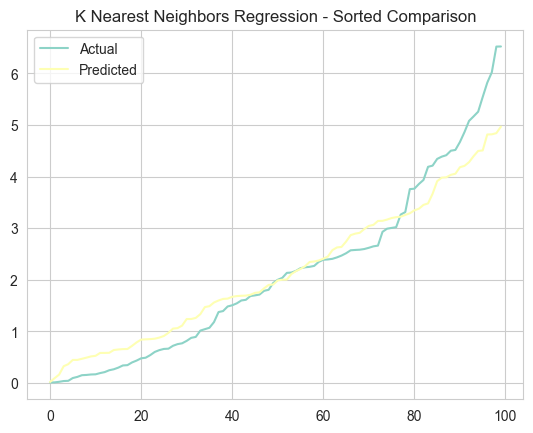

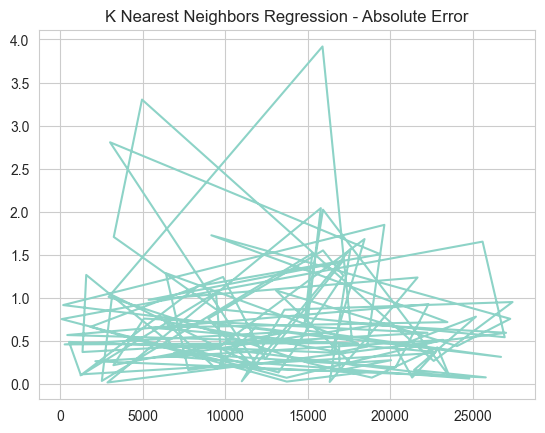


------------------------------------------------------------



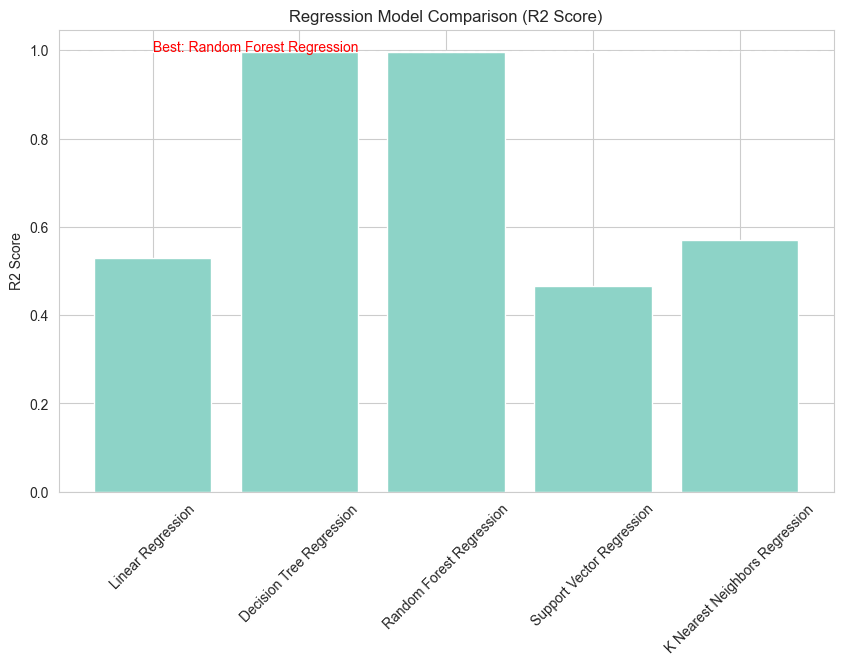

In [124]:
import matplotlib.pyplot as plt
import numpy as np

r2_scores = []
model_names = []

for name, model in models.items():

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    r2_scores.append(r2)
    model_names.append(name)

    print("Model:", name)
    print("R2 Score:", r2)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("Train:", model.score(x_train, y_train))
    print("Test:", model.score(x_test, y_test))

    #  Scatter Plot
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} - Actual vs Predicted")
    plt.show()

    #  Line Plot
    plt.figure()
    plt.plot(y_test.values[:100], label='Actual')
    plt.plot(y_pred[:100], label='Predicted')
    plt.legend()                #Shows label: Actual line, Predicted line
    plt.title(f"{name} - Comparison")
    plt.show()

    #  Residual Plot        To check: does error increase with prediction?
    residuals = y_test - y_pred             #big value → big error
    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0)
    plt.title(f"{name} - Residual Plot")
    plt.show()

    #  Error Distribution
    plt.figure()
    plt.hist(residuals, bins=30)        #distribution of values in 30 group
    plt.title(f"{name} - Error Distribution")
    plt.show()

    #  Sorted Comparison
    plt.figure()
    plt.plot(sorted(y_test.values[:100]), label='Actual')
    plt.plot(sorted(y_pred[:100]), label='Predicted')
    plt.legend()
    plt.title(f"{name} - Sorted Comparison")
    plt.show()

    #  Absolute Error
    abs_error = np.abs(y_test - y_pred)

    plt.figure()
    plt.plot(abs_error[:100])
    plt.title(f"{name} - Absolute Error")
    plt.show()

    print("\n" + "-"*60 + "\n")


#  FINAL REGRESSION COMPARISON
plt.figure(figsize=(10,6))
plt.bar(model_names, r2_scores)
plt.xticks(rotation=45)
plt.title("Regression Model Comparison (R2 Score)")
plt.ylabel("R2 Score")

best_idx = np.argmax(r2_scores)
plt.axhline(r2_scores[best_idx], linestyle='--')
plt.text(0, r2_scores[best_idx], f"Best: {model_names[best_idx]}", color='red')

plt.show()

In [125]:
print(data.corr()["petrol_usd_liter"].sort_values(ascending=False))

petrol_usd_liter    1.000000
lpg_usd_liter       0.999917
diesel_usd_liter    0.999045
tax_percentage      0.522155
brent_crude_usd     0.263530
region              0.042099
month               0.017594
country            -0.011574
subsidy_level      -0.315061
income_level       -0.548275
Name: petrol_usd_liter, dtype: float64


Classification Model Training

Label Encoding

In [126]:
le = LabelEncoder()

for col in ['country','region','income_level','subsidy_level']:
    data[col] = le.fit_transform(data[col])
data

,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,month
0,79,4,0,1,1.465,1.289,1.093,65.75,59.6,1
1,79,4,0,1,1.435,1.319,1.077,65.54,27.6,1
2,79,4,0,1,1.446,1.329,1.080,66.51,62.3,1
3,79,4,0,1,1.488,1.359,1.125,68.79,44.8,1
4,79,4,0,1,1.457,1.341,1.111,68.44,51.4,2
...,...,...,...,...,...,...,...,...,...,...
27463,59,0,1,1,3.036,2.849,2.294,130.00,62.3,3
27464,59,0,1,1,3.020,2.861,2.248,130.00,43.3,3
27465,59,0,1,1,3.072,2.825,2.334,130.00,64.1,3
27466,59,0,1,1,3.045,2.816,2.282,130.00,43.7,3


Feature Extraction

In [127]:
x_new=data.drop('income_level',axis=1)
y_new=data['income_level']

StandardScale

In [128]:
scale=StandardScaler()
x_new=scale.fit_transform(x_new)


In [129]:
data.corr()["income_level"].sort_values(ascending=False)

income_level        1.000000e+00
subsidy_level       9.652457e-02
brent_crude_usd     8.106669e-15
month              -1.425741e-15
country            -4.324945e-03
region             -5.987547e-02
tax_percentage     -3.400340e-01
petrol_usd_liter   -5.482754e-01
lpg_usd_liter      -5.483318e-01
diesel_usd_liter   -5.546607e-01
Name: income_level, dtype: float64

Check “Copying”

In [130]:
data.corr()

,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,month
country,1.000000e+00,-1.844587e-01,-4.324945e-03,-5.888582e-02,-0.011574,-0.017104,-0.011356,4.546747e-15,0.060722,-7.153318e-16
region,-1.844587e-01,1.000000e+00,-5.987547e-02,1.055311e-02,0.042099,0.042666,0.042178,-2.092046e-14,-0.043108,2.799321e-15
income_level,-4.324945e-03,-5.987547e-02,1.000000e+00,9.652457e-02,-0.548275,-0.554661,-0.548332,8.106669e-15,-0.340034,-1.425741e-15
subsidy_level,-5.888582e-02,1.055311e-02,9.652457e-02,1.000000e+00,-0.315061,-0.314924,-0.314827,8.014381e-15,-0.251448,-1.305238e-15
petrol_usd_liter,-1.157396e-02,4.209863e-02,-5.482754e-01,-3.150612e-01,1.000000,0.999045,0.999917,2.635300e-01,0.522155,1.759429e-02
diesel_usd_liter,-1.710418e-02,4.266642e-02,-5.546607e-01,-3.149238e-01,0.999045,1.000000,0.998964,2.588479e-01,0.522029,1.728090e-02
lpg_usd_liter,-1.135617e-02,4.217828e-02,-5.483318e-01,-3.148274e-01,0.999917,0.998964,1.000000,2.634895e-01,0.522152,1.758256e-02
brent_crude_usd,4.546747e-15,-2.092046e-14,8.106669e-15,8.014381e-15,0.263530,0.258848,0.263490,1.000000e+00,0.000568,6.707001e-02
tax_percentage,6.072176e-02,-4.310753e-02,-3.400340e-01,-2.514480e-01,0.522155,0.522029,0.522152,5.682524e-04,1.000000,2.479250e-03
month,-7.153318e-16,2.799321e-15,-1.425741e-15,-1.305238e-15,0.017594,0.017281,0.017583,6.707001e-02,0.002479,1.000000e+00


In [131]:
x_new_test,x_new_train,y_new_test,y_new_train=train_test_split(x_new,y_new,test_size=0.2,random_state=42)

Model Training

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

In [133]:
modelss = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree Classification": DecisionTreeClassifier(),
    "Random Forest Classification": RandomForestClassifier(n_estimators=200, max_depth=10),
    "Support Vector Classification": SVC(),
    "K Nearest Neighbors Classification": KNeighborsClassifier(),
    "Naive Bayes Classification": GaussianNB()
}

Model: Logistic Regression
Accuracy: 0.7357786474924911
Train: 0.7499089916272297
Test: 0.7357786474924911

Confusion Matrix:
 [[7132   12 1198]
 [  25 4821 1147]
 [1425 1999 4215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84      8342
           1       0.71      0.80      0.75      5993
           2       0.64      0.55      0.59      7639

    accuracy                           0.74     21974
   macro avg       0.73      0.74      0.73     21974
weighted avg       0.73      0.74      0.73     21974

 No strong overfitting
Original: 0.7357786474924911
Shuffled: 0.3358514608173296
CV Mean: 0.7484513989369372


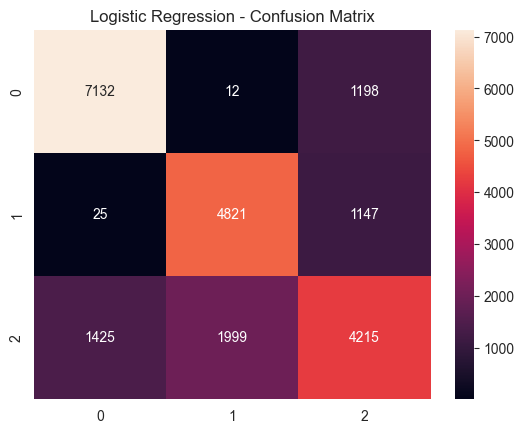

<Figure size 640x480 with 0 Axes>

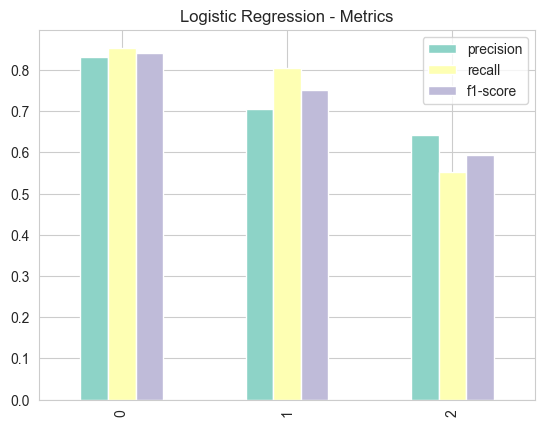

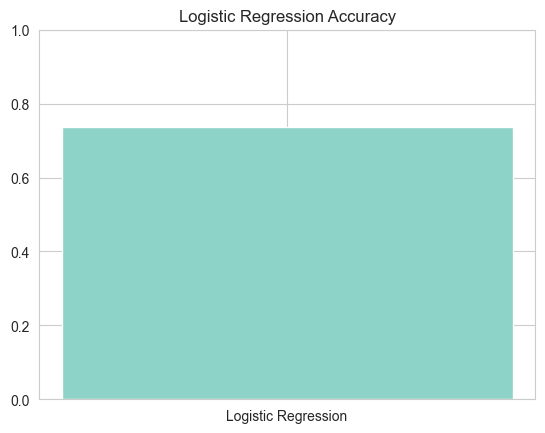

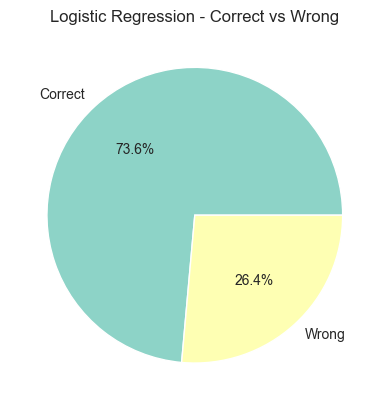

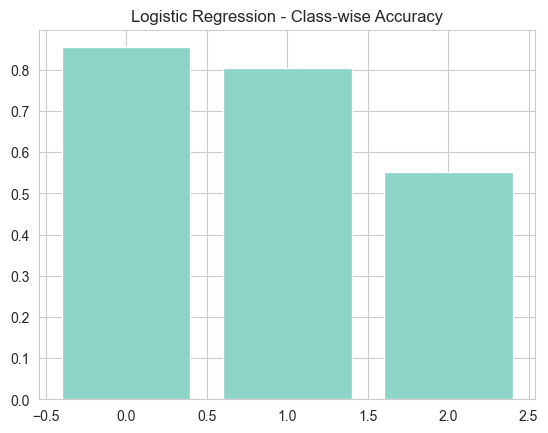

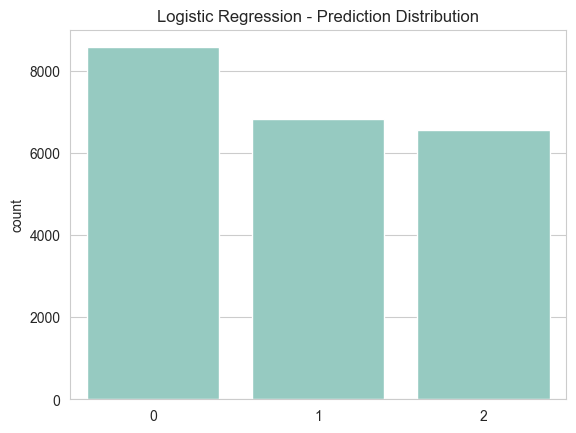


------------------------------------------------------------

Model: Decision Tree Classification
Accuracy: 0.9950851005734049
Train: 1.0
Test: 0.9950851005734049

Confusion Matrix:
 [[8270    0   72]
 [   0 5993    0]
 [  23   13 7603]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      8342
           1       1.00      1.00      1.00      5993
           2       0.99      1.00      0.99      7639

    accuracy                           1.00     21974
   macro avg       1.00      1.00      1.00     21974
weighted avg       1.00      1.00      1.00     21974

 No strong overfitting
Original: 0.9950851005734049
Shuffled: 0.3383089105306271
CV Mean: 0.9938113966828596


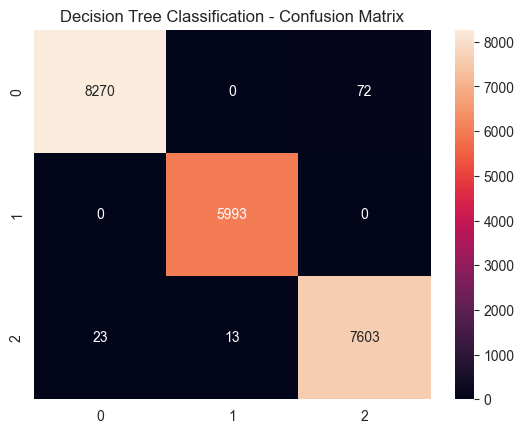

<Figure size 640x480 with 0 Axes>

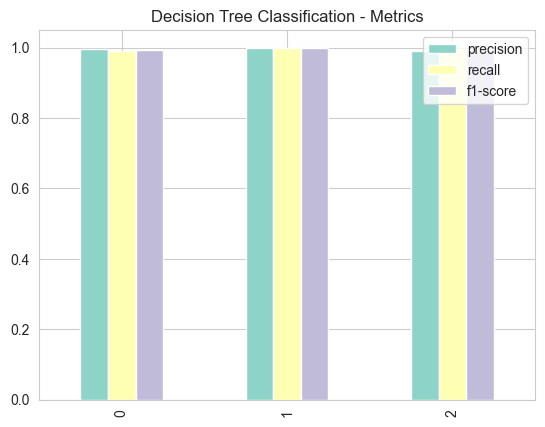

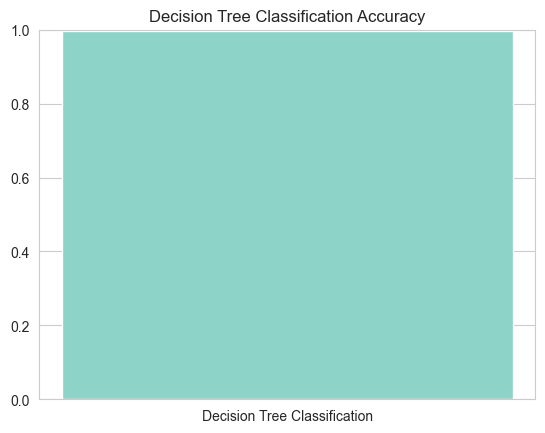

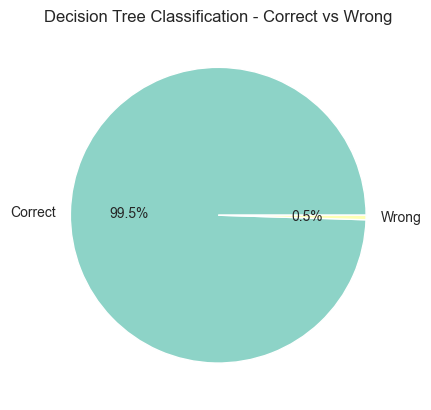

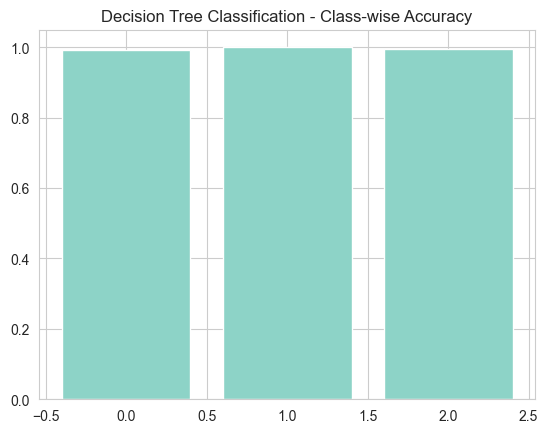

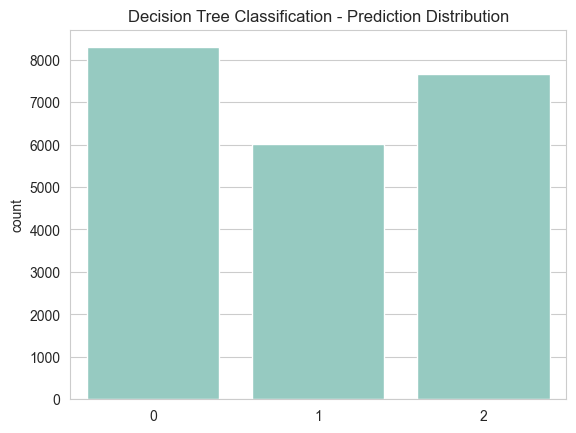


------------------------------------------------------------

Model: Random Forest Classification
Accuracy: 0.983981068535542
Train: 0.9939934473971606
Test: 0.983981068535542

Confusion Matrix:
 [[8312    0   30]
 [   0 5991    2]
 [  12  308 7319]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8342
           1       0.95      1.00      0.97      5993
           2       1.00      0.96      0.98      7639

    accuracy                           0.98     21974
   macro avg       0.98      0.98      0.98     21974
weighted avg       0.98      0.98      0.98     21974

 No strong overfitting
Original: 0.983981068535542
Shuffled: 0.33535086920906526
CV Mean: 0.9834376672948251


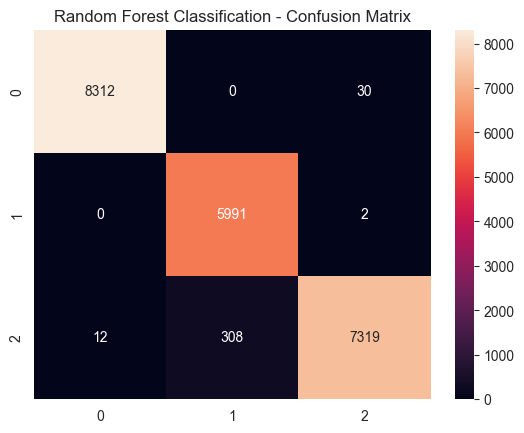

<Figure size 640x480 with 0 Axes>

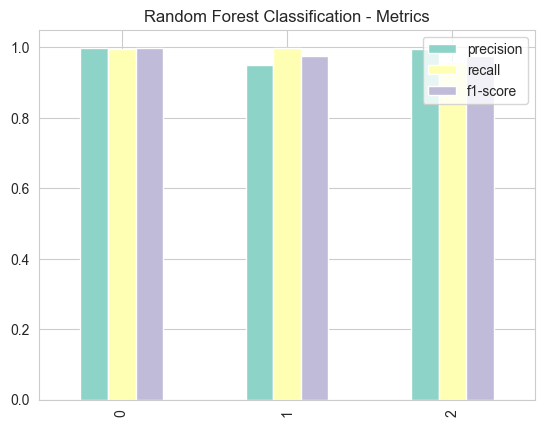

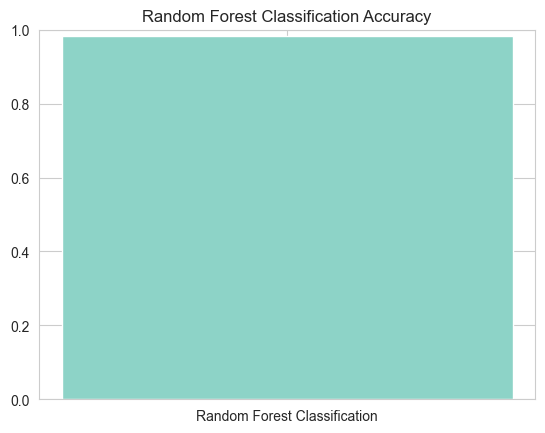

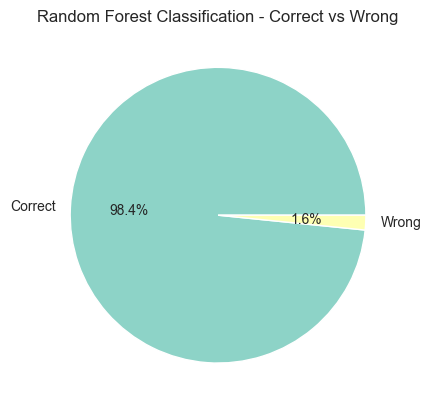

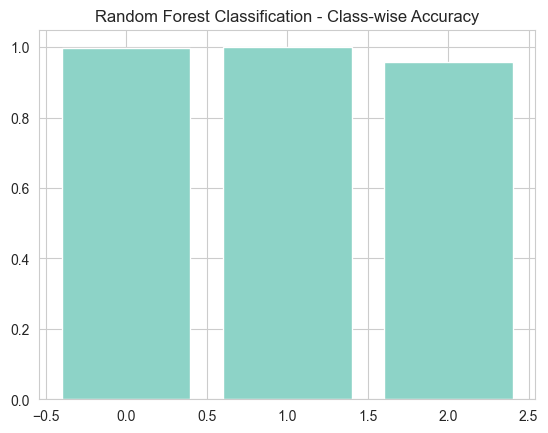

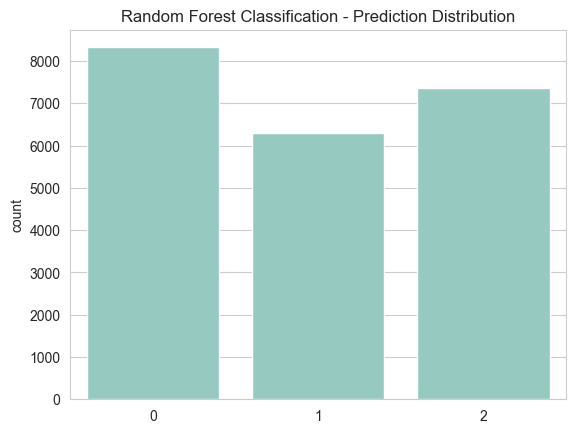


------------------------------------------------------------

Model: Support Vector Classification
Accuracy: 0.8735778647492491
Train: 0.8851474335638879
Test: 0.8735778647492491

Confusion Matrix:
 [[7807    0  535]
 [   0 5098  895]
 [ 227 1121 6291]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95      8342
           1       0.82      0.85      0.83      5993
           2       0.81      0.82      0.82      7639

    accuracy                           0.87     21974
   macro avg       0.87      0.87      0.87     21974
weighted avg       0.88      0.87      0.87     21974

 No strong overfitting
Original: 0.8735778647492491
Shuffled: 0.3328024028397197
CV Mean: 0.8689484230572255


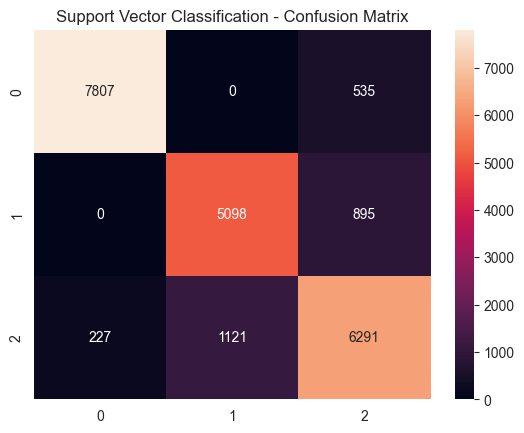

<Figure size 640x480 with 0 Axes>

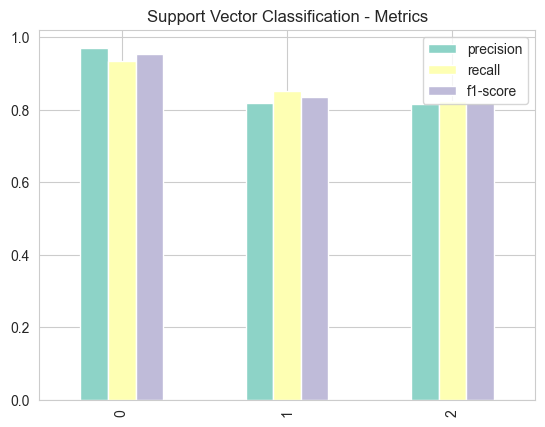

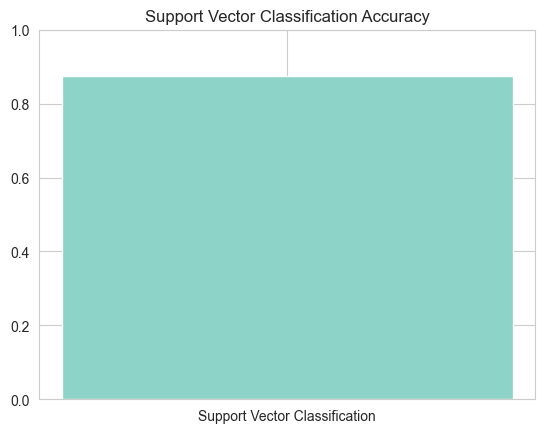

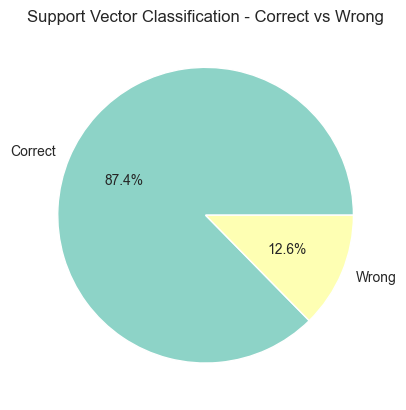

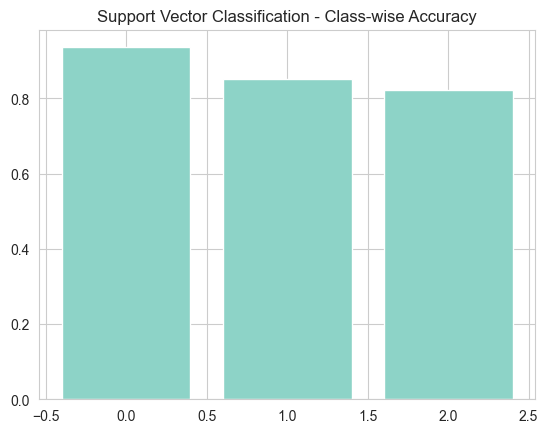

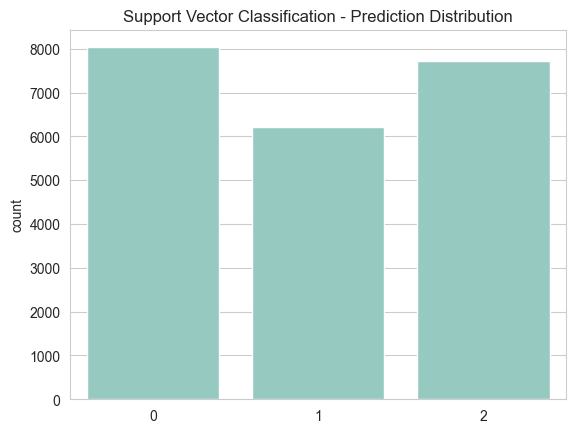


------------------------------------------------------------

Model: K Nearest Neighbors Classification
Accuracy: 0.9206334759260945
Train: 0.9585001820167456
Test: 0.9206334759260945

Confusion Matrix:
 [[8125   20  197]
 [  17 5447  529]
 [ 126  855 6658]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      8342
           1       0.86      0.91      0.88      5993
           2       0.90      0.87      0.89      7639

    accuracy                           0.92     21974
   macro avg       0.92      0.92      0.92     21974
weighted avg       0.92      0.92      0.92     21974

 No strong overfitting
Original: 0.9206334759260945
Shuffled: 0.34640939291890416
CV Mean: 0.9129964150221015


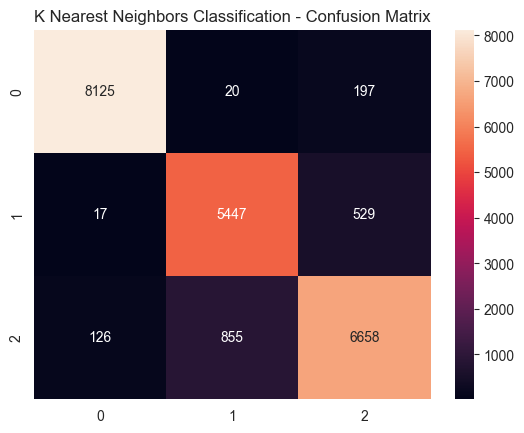

<Figure size 640x480 with 0 Axes>

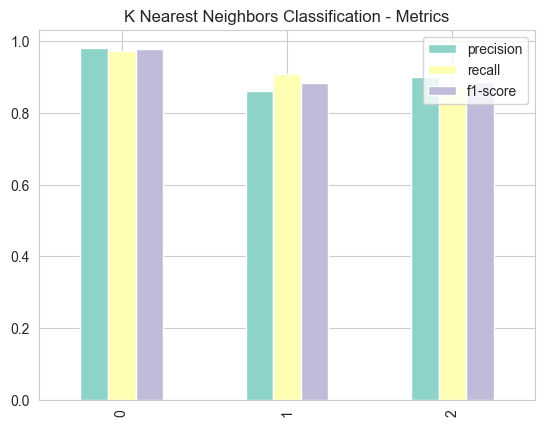

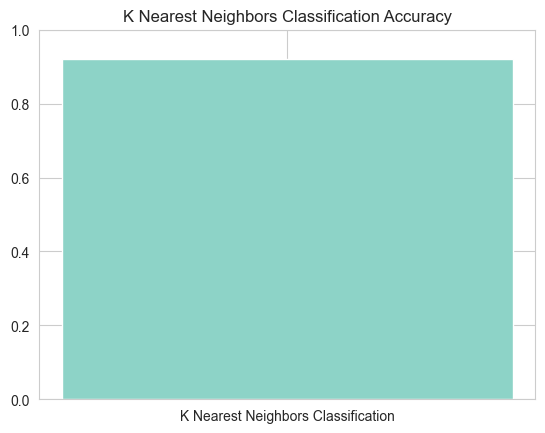

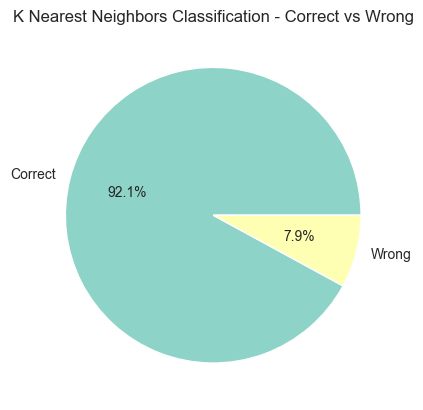

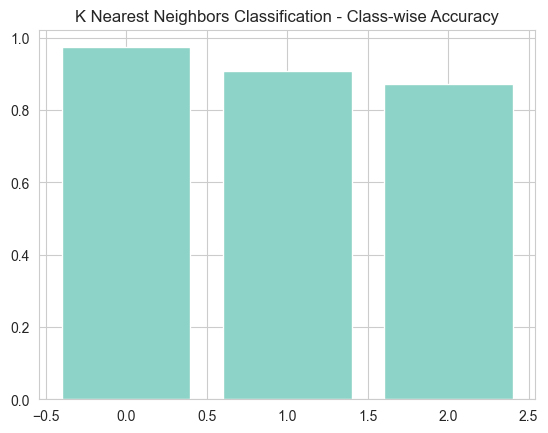

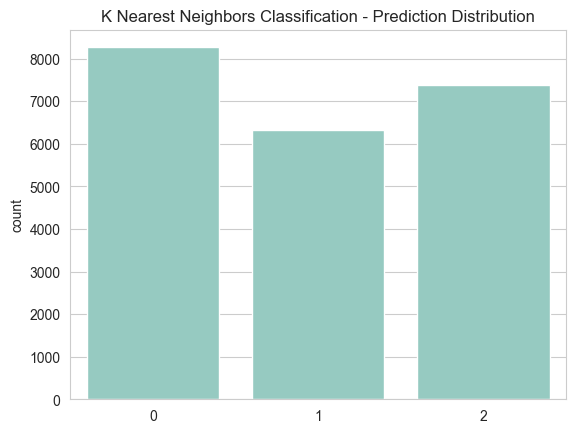


------------------------------------------------------------

Model: Naive Bayes Classification
Accuracy: 0.6824883953763539
Train: 0.6967601019293775
Test: 0.6824883953763539

Confusion Matrix:
 [[6687   69 1586]
 [ 633 4625  735]
 [1380 2574 3685]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.78      8342
           1       0.64      0.77      0.70      5993
           2       0.61      0.48      0.54      7639

    accuracy                           0.68     21974
   macro avg       0.67      0.69      0.67     21974
weighted avg       0.68      0.68      0.68     21974

 No strong overfitting
Original: 0.6824883953763539
Shuffled: 0.33899153545098754
CV Mean: 0.6983961243123821


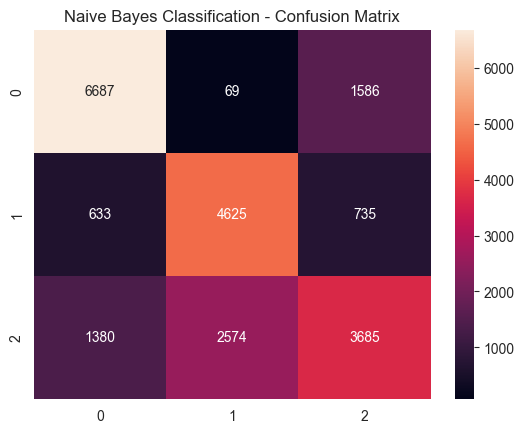

<Figure size 640x480 with 0 Axes>

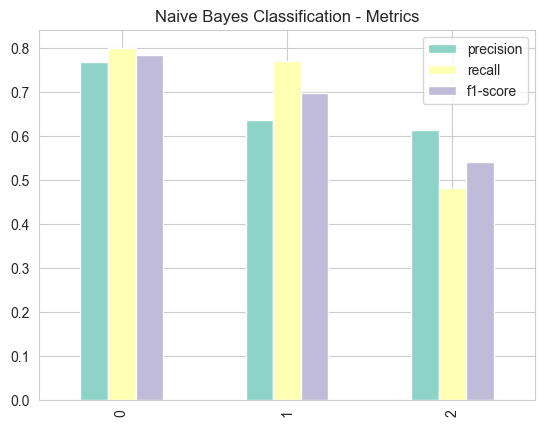

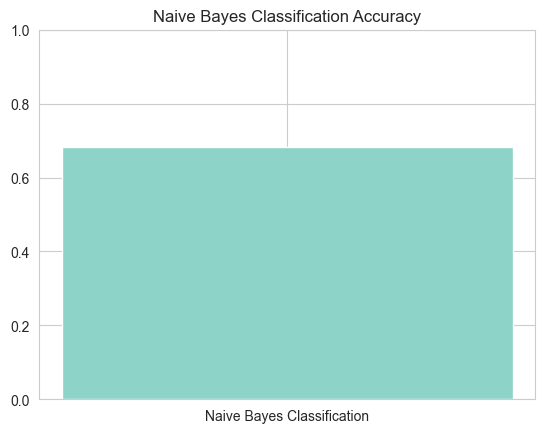

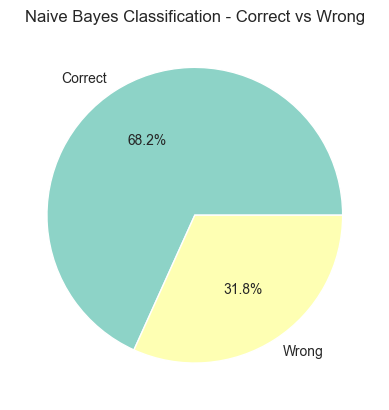

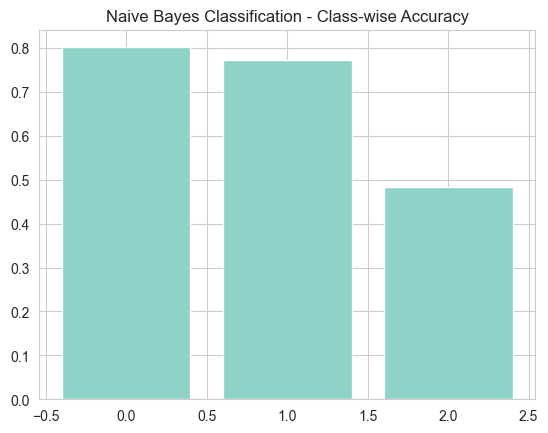

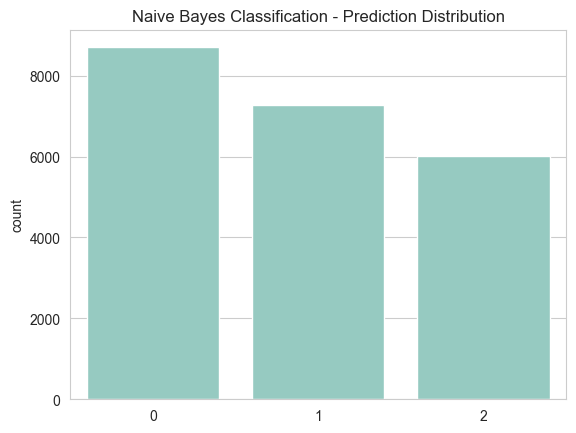


------------------------------------------------------------



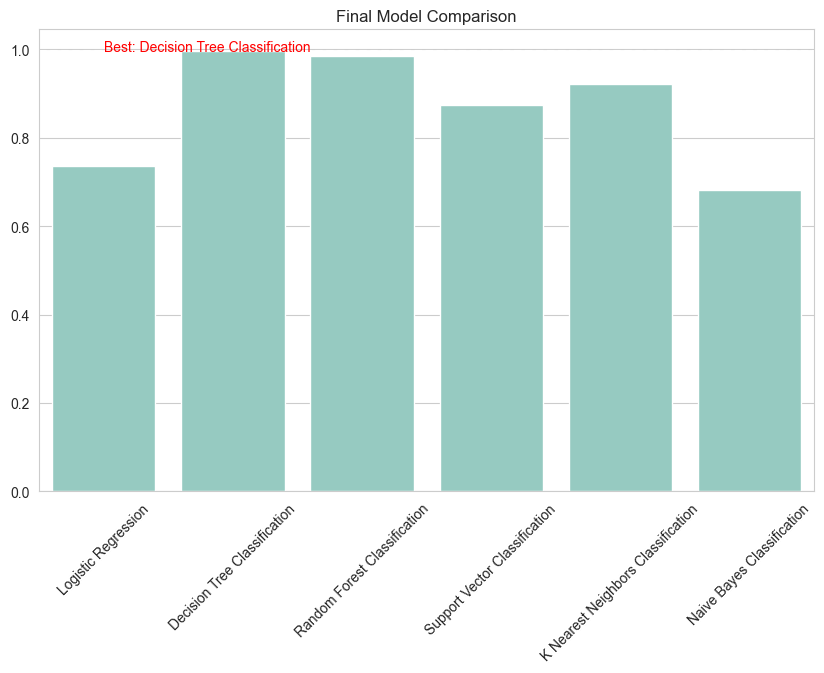

In [141]:
import seaborn as sns
import pandas as pd

acc_results = {}

for name, model in modelss.items():

    model.fit(x_new_train, y_new_train)
    y_new_pred = model.predict(x_new_test)

    ac = accuracy_score(y_new_test, y_new_pred)
    cm = confusion_matrix(y_new_test, y_new_pred)
    cr = classification_report(y_new_test, y_new_pred)

    acc_results[name] = ac

    print("Model:", name)
    print("Accuracy:", ac)
    print("Train:", model.score(x_new_train, y_new_train))
    print("Test:", model.score(x_new_test, y_new_test))

    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", cr)

    #  Overfitting
    if model.score(x_new_train, y_new_train) - model.score(x_new_test, y_new_test) > 0.1:
        print(" Overfitting detected")
    else:
        print(" No strong overfitting")

    #  Shuffle Test
    y_shuffled = np.random.permutation(y_new_test)
    shuffled_score = model.score(x_new_test, y_shuffled)

    print("Original:", ac)
    print("Shuffled:", shuffled_score)

    #  Cross Validation
    cv = cross_val_score(model, x_new_train, y_new_train, cv=5)
    print("CV Mean:", cv.mean())

    #  Confusion Matrix Heatmap
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    #  Precision / Recall / F1 Bar
    report_dict = classification_report(y_new_test, y_new_pred, output_dict=True)
    df = pd.DataFrame(report_dict).transpose()

    plt.figure()
    df[['precision','recall','f1-score']].iloc[:-3].plot(kind='bar')
    plt.title(f"{name} - Metrics")
    plt.show()

    #  Accuracy Bar
    plt.figure()
    plt.bar([name], [ac])
    plt.ylim(0,1)
    plt.title(f"{name} Accuracy")
    plt.show()

    #  Pie Chart
    correct = (y_new_test == y_new_pred).sum()
    wrong = (y_new_test != y_new_pred).sum()

    plt.figure()
    plt.pie([correct, wrong], labels=['Correct','Wrong'], autopct='%1.1f%%')
    plt.title(f"{name} - Correct vs Wrong")
    plt.show()

    #  Class-wise Accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure()
    plt.bar(range(len(class_acc)), class_acc)
    plt.title(f"{name} - Class-wise Accuracy")
    plt.show()

    #  Prediction Distribution
    plt.figure()
    sns.countplot(x=y_new_pred)
    plt.title(f"{name} - Prediction Distribution")
    plt.show()

    print("\n" + "-"*60 + "\n")


#  FINAL COMPARISON
plt.figure(figsize=(10,6))
sns.barplot(x=list(acc_results.keys()), y=list(acc_results.values()))
plt.xticks(rotation=45)
plt.title("Final Model Comparison")

best_model = max(acc_results, key=acc_results.get)
plt.axhline(acc_results[best_model], linestyle='--')
plt.text(0, acc_results[best_model], f"Best: {best_model}", color='red')

plt.show()


Analysis for: Logistic Regression


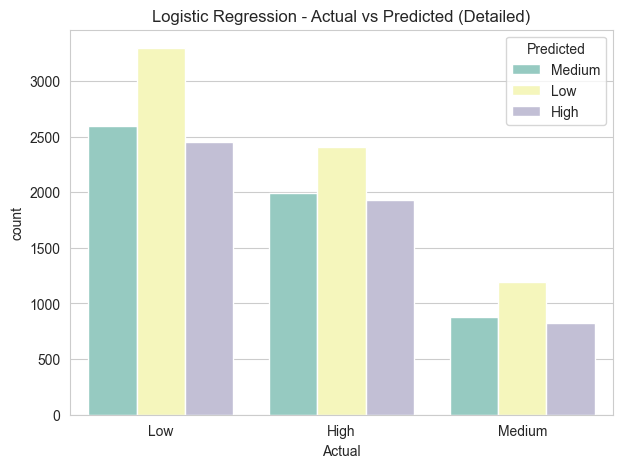

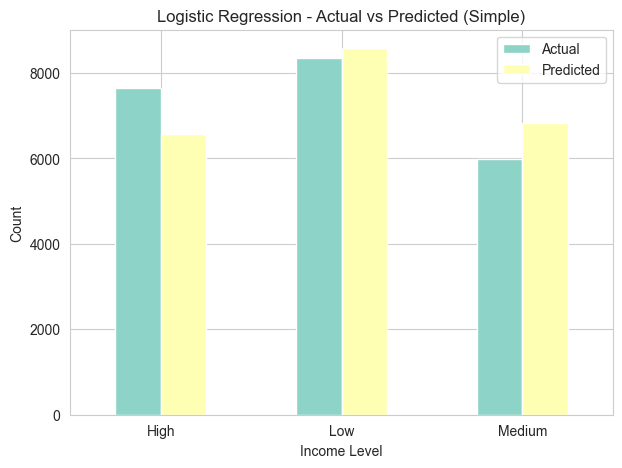

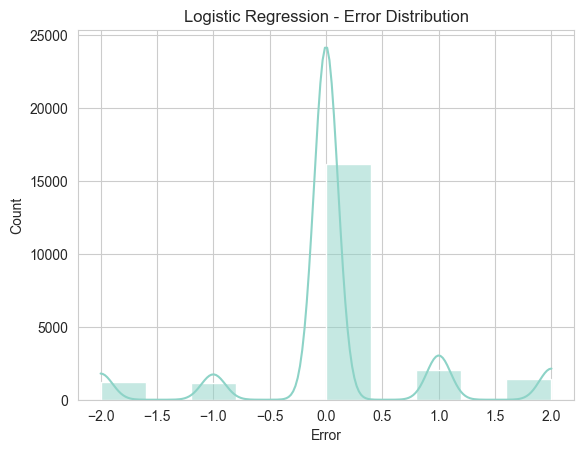

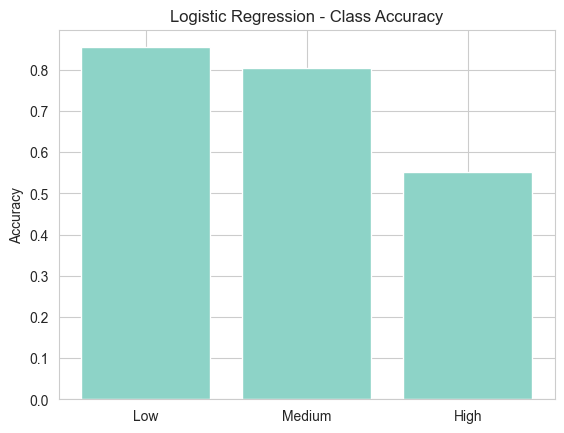

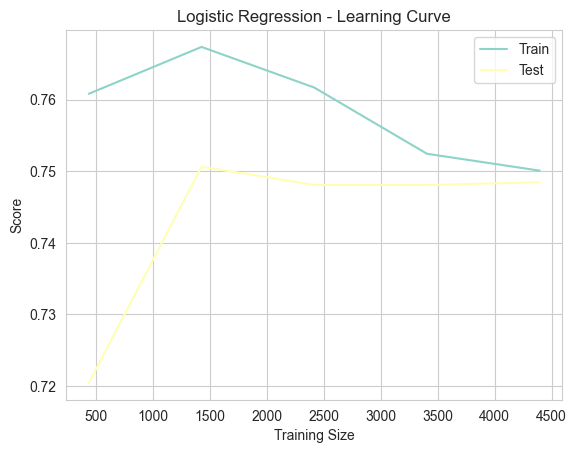

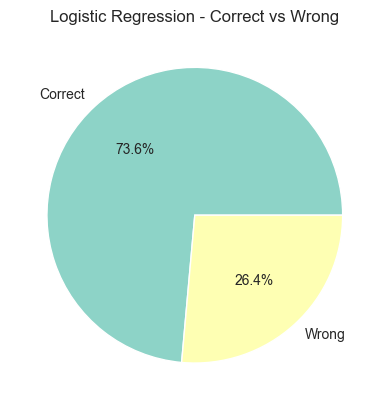


Analysis for: Decision Tree Classification


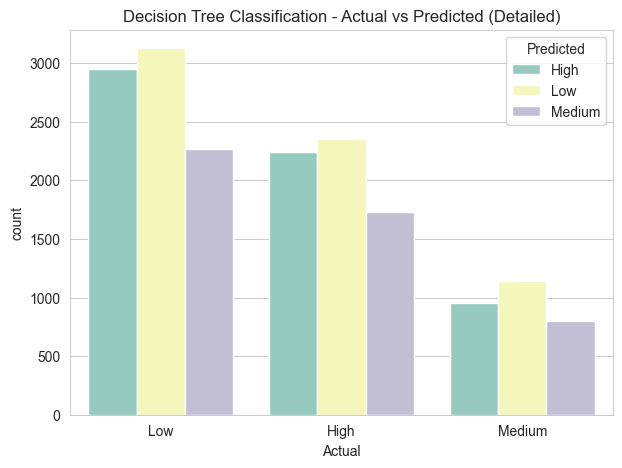

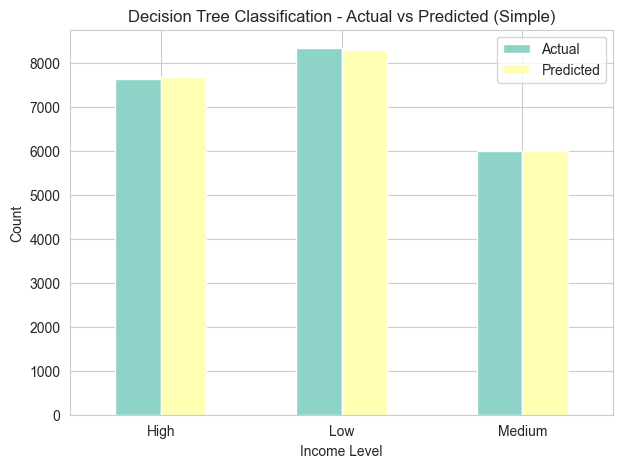

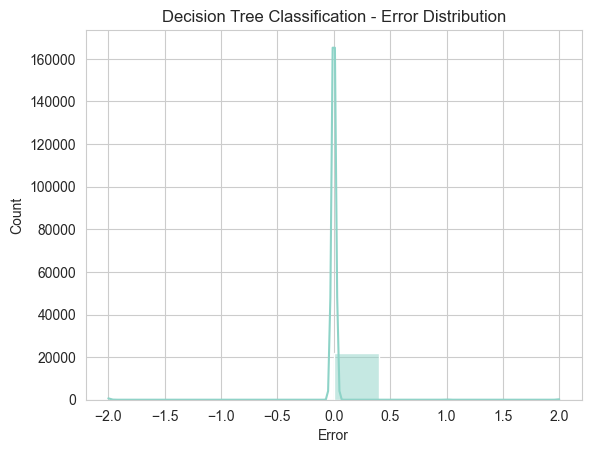

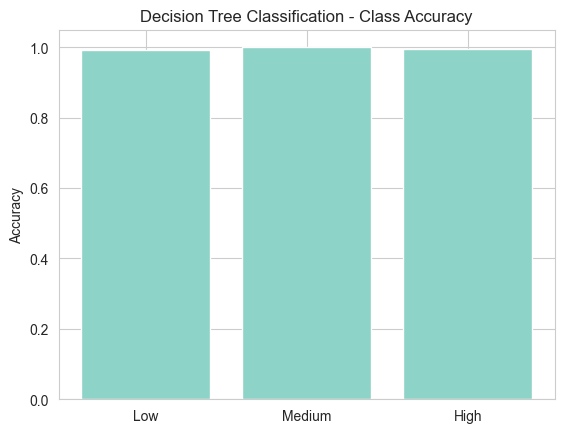

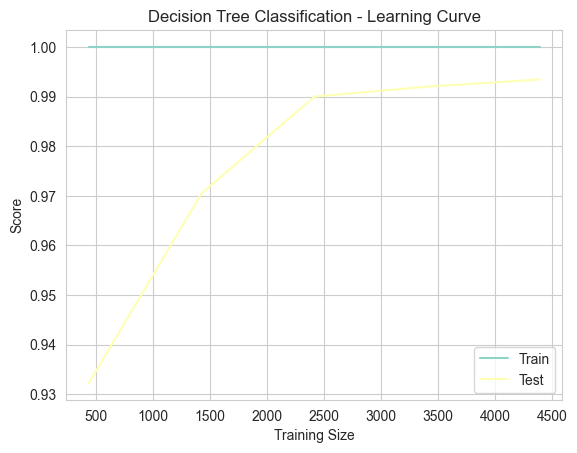

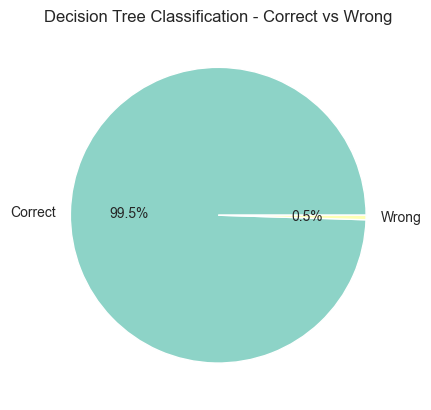


Analysis for: Random Forest Classification


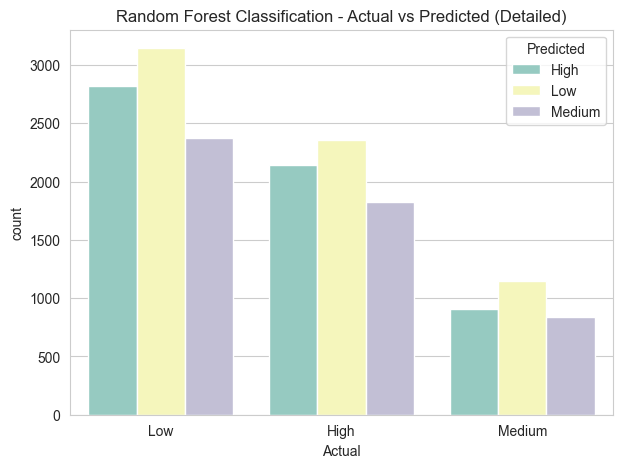

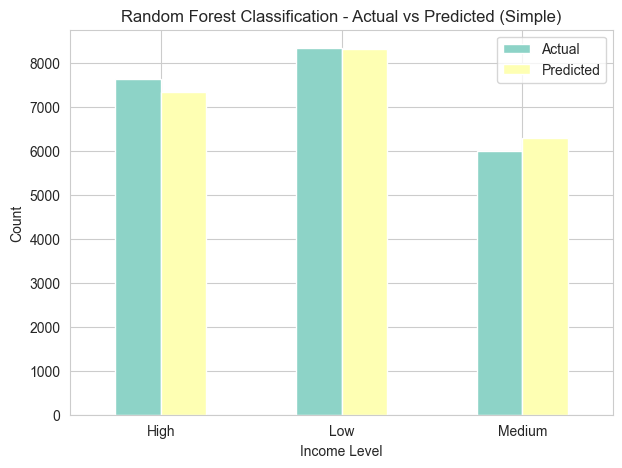

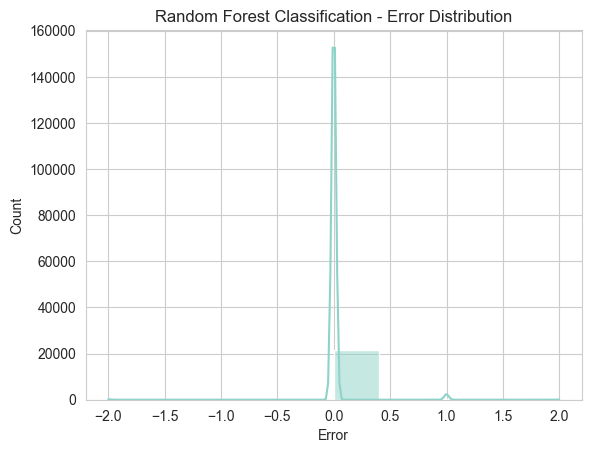

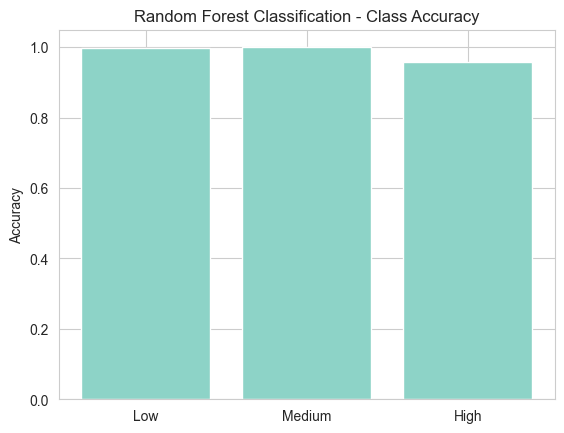

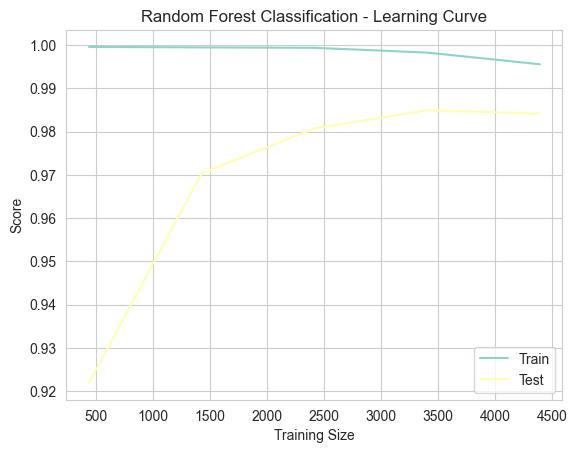

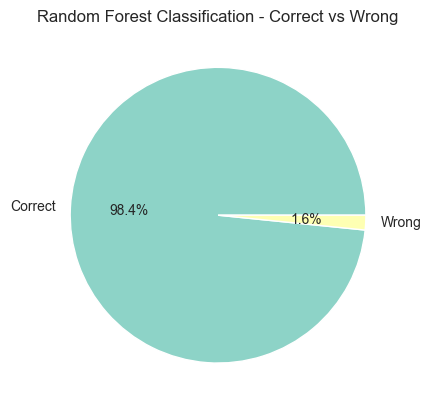


Analysis for: Support Vector Classification


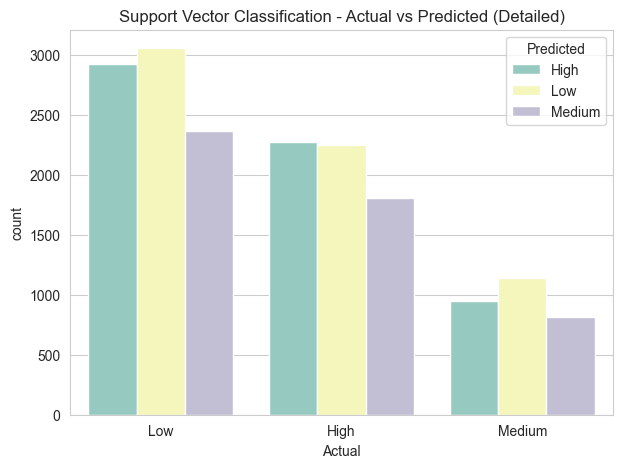

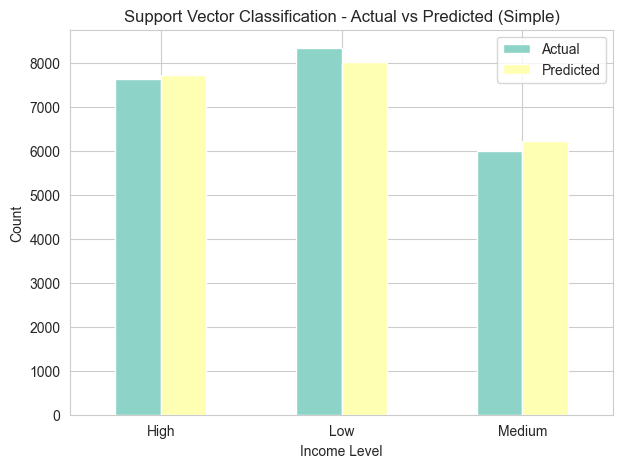

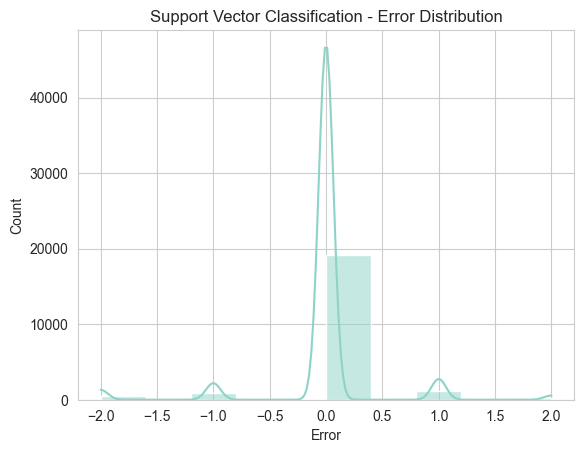

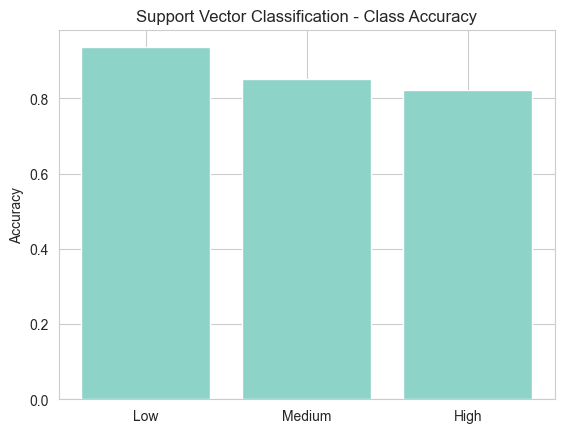

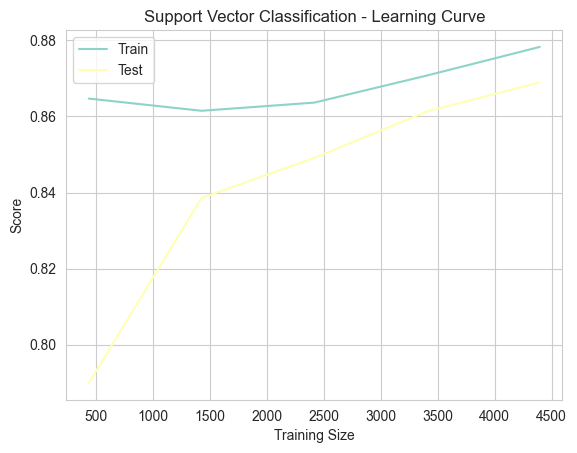

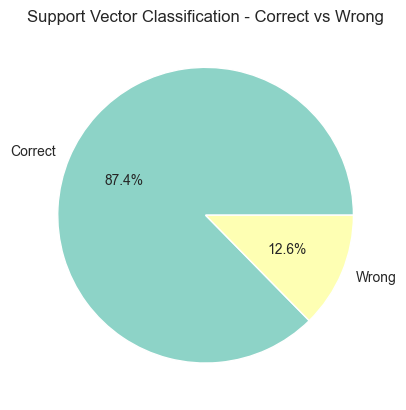


Analysis for: K Nearest Neighbors Classification


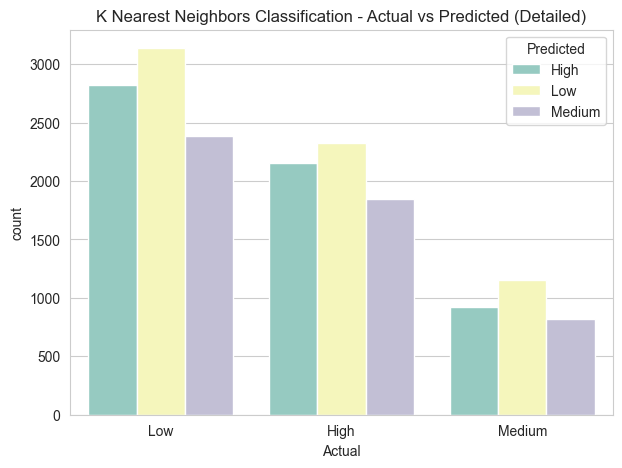

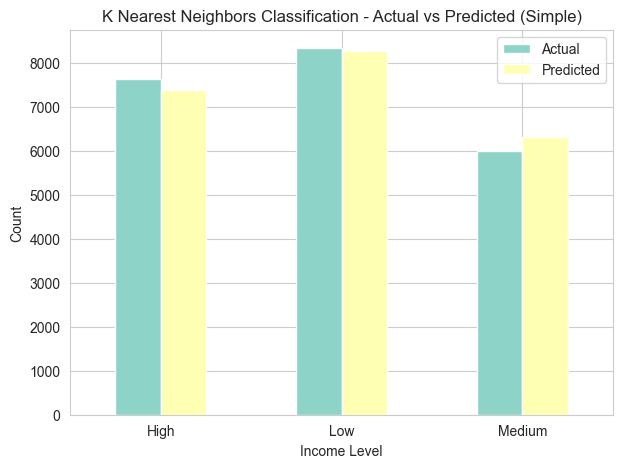

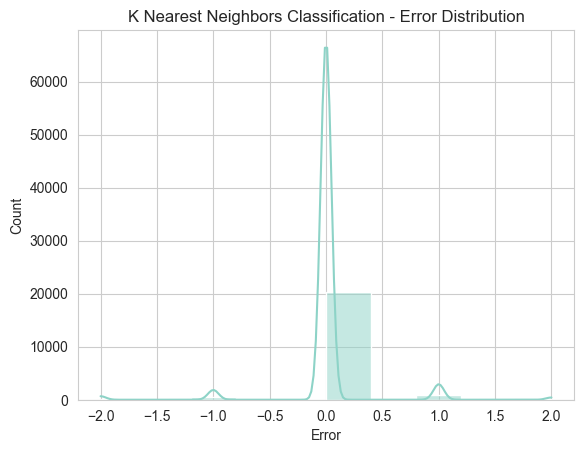

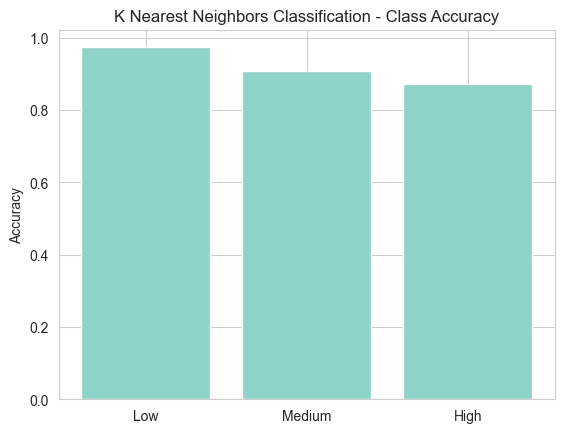

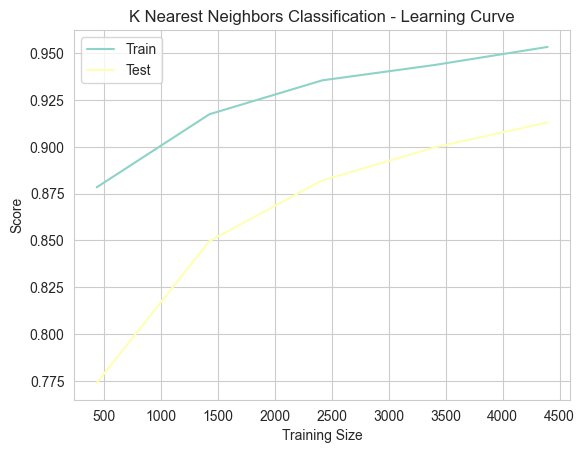

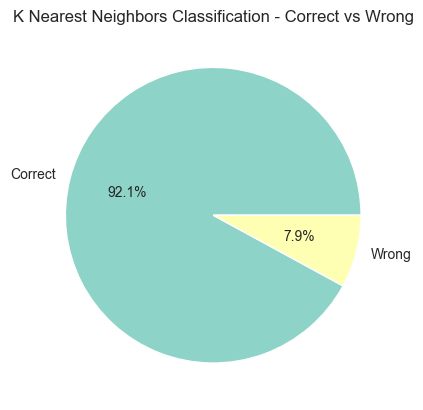


Analysis for: Naive Bayes Classification


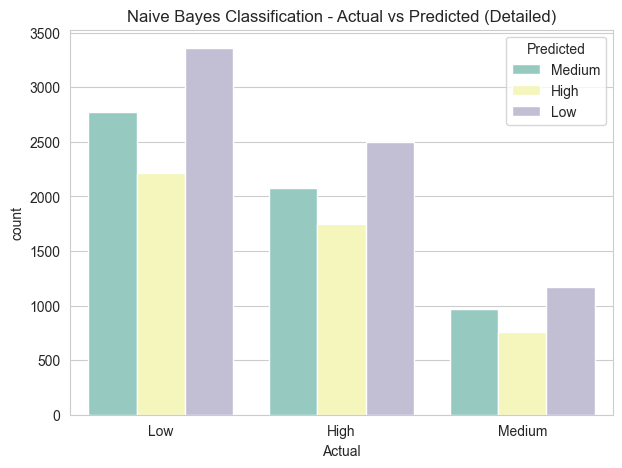

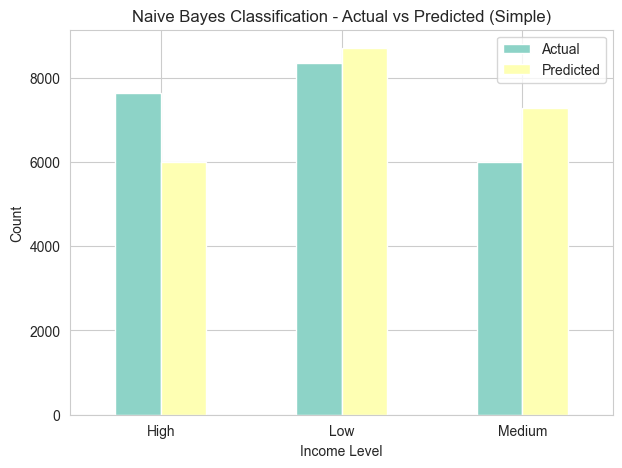

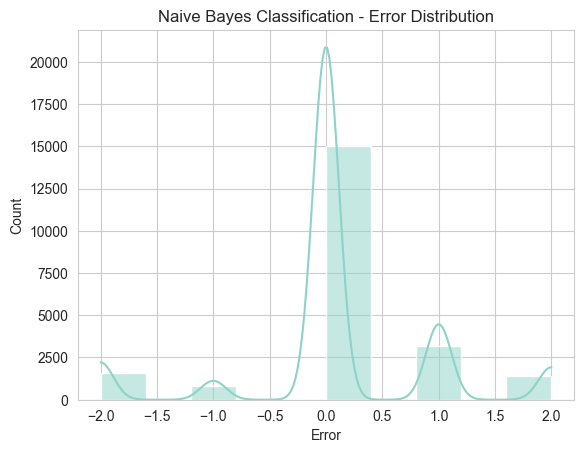

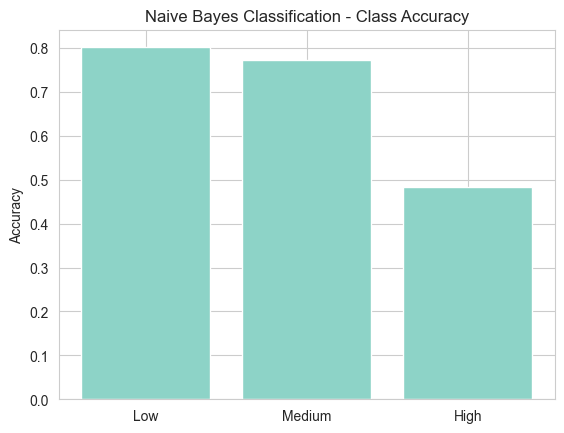

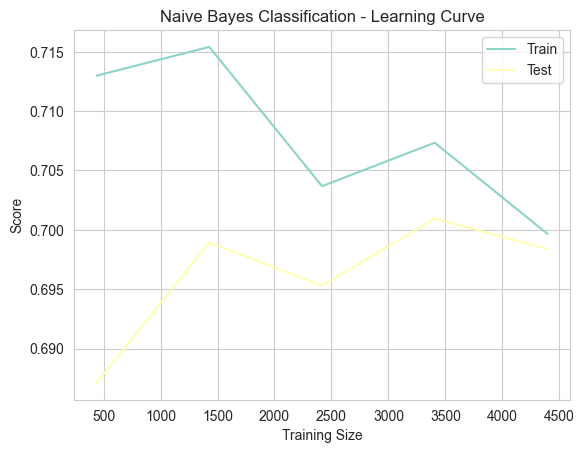

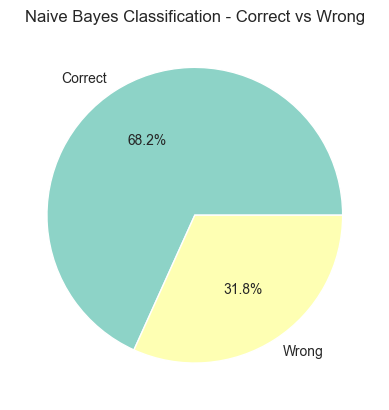

In [145]:
from sklearn.model_selection import learning_curve

# Label mapping
label_map = {0: "Low", 1: "Medium", 2: "High"}

for name, model in modelss.items():

    print("\n==============================")
    print("Analysis for:", name)
    print("==============================")

    # Predict
    y_pred = model.predict(x_new_test)

    # Convert labels
    actual_labels = pd.Series(y_new_test).map(label_map)
    pred_labels = pd.Series(y_pred).map(label_map)


    # Actual vs Predicted (YOUR ORIGINAL)

    compare_df = pd.DataFrame({
        "Actual": actual_labels,
        "Predicted": pred_labels
    })

    plt.figure(figsize=(7,5))
    sns.countplot(x="Actual", hue="Predicted", data=compare_df)
    plt.title(f"{name} - Actual vs Predicted (Detailed)")
    plt.show()

    #  SIMPLE 2-BAR COMPARISON (BEST)

    actual_counts = actual_labels.value_counts().sort_index()
    pred_counts = pred_labels.value_counts().sort_index()

    df_bar = pd.DataFrame({
        "Actual": actual_counts,
        "Predicted": pred_counts
    }).fillna(0)

    df_bar.plot(kind='bar', figsize=(7,5))
    plt.title(f"{name} - Actual vs Predicted (Simple)")
    plt.xlabel("Income Level")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()


    #  Error Distribution

    errors = y_new_test - y_pred

    plt.figure()
    sns.histplot(errors, bins=10, kde=True)
    plt.title(f"{name} - Error Distribution")
    plt.xlabel("Error")
    plt.show()


    #  Class-wise Accuracy

    cm = confusion_matrix(y_new_test, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure()
    plt.bar(["Low","Medium","High"], class_acc)
    plt.title(f"{name} - Class Accuracy")
    plt.ylabel("Accuracy")
    plt.show()


    #Learning Curve

    try:
        train_sizes, train_scores, test_scores = learning_curve(
            model,
            x_new_train,
            y_new_train,
            cv=5
        )

        plt.figure()
        plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
        plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")
        plt.title(f"{name} - Learning Curve")
        plt.xlabel("Training Size")
        plt.ylabel("Score")
        plt.legend()
        plt.show()

    except:
        print(f"{name} - Learning curve skipped")


    # Correct vs Wrong

    correct = (y_new_test == y_pred).sum()
    wrong = (y_new_test != y_pred).sum()

    plt.figure()
    plt.pie([correct, wrong], labels=["Correct","Wrong"], autopct='%1.1f%%')
    plt.title(f"{name} - Correct vs Wrong")
    plt.show()